# Full versus exclusive fate markers: size-conditioned FiLM ablation

This experiment uses only the **depth-two FiLM model with log cell count in FiLM and the head, and no global geometry in the head**. The exclusive model retains the original seven binary feature columns, with at most one positive entry. All-zero cells remain all zero. The original files and completed full-marker experiment are preserved.

Rules are applied in their supplied dictionary order: clear the named marker whenever any listed exclusion is *currently* positive, then continue to the next rule. Absent dataset markers are ignored. This is not the older export utility's rule evaluation against the original matrix.

For a controlled comparison, the original 1,100-organoid cohort, five folds, three seeds, baseline models, target transform, geometric calibration and N grid are reused. The 15 exclusive models are trained with the original hyperparameters and common-weight initialization. Full-marker checkpoints are reused and their validation predictions are rechecked against the saved results.

The default execution reads completed cached outputs. The switches below separately enable training, extended inference and summary recomputation.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/models/gnn.py').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
REFERENCE_RUN = PROJECT_ROOT / 'results_experiments/size_conditioned_ablation/20260910_164825_all_depth2_four_models_baseline_with_size'
COMPARISON_DIR = PROJECT_ROOT / 'results_experiments/size_conditioned_exclusive/20260914_ordered_exclusive_film_depth2'
EXCLUSIVE_RUN = COMPARISON_DIR / 'exclusive'
RUN_TRAINING_AND_MAIN_ABLATIONS = False
RUN_EXTENDED_DIAGNOSTICS = False
RECOMPUTE_SUMMARIES = False
from src.data.marker_exclusivity import EXCLUSIVITY_RULES
print(json.dumps(EXCLUSIVITY_RULES, indent=2))
settings = json.loads((EXCLUSIVE_RUN / 'settings.json').read_text())
display(pd.Series({k: settings[k] for k in ['DATASET_NAME','MODEL_NAMES','MODEL_GLOBAL_FEATURES','NUM_LAYERS','HIDDEN_DIM',
    'FILM_HIDDEN_DIM','MODEL_SEEDS','MAX_EPOCHS','PATIENCE','LR','BATCH_SIZE','APPLY_SPHERICITY_FILTER','SPHERICITY_MAX',
    'SUBTRACT_CONSTANT_GLOBAL_BASELINE','BASELINE_FEATURES','BASELINE_REUSED']}, name='Experiment settings'))


{
  "LGR5": [
    "Chroma",
    "Mucin 2",
    "AldoB",
    "Glucagon",
    "Agr2",
    "Serotonin",
    "Lysozyme"
  ],
  "Chroma": [
    "Mucin 2",
    "Glucagon",
    "Serotonin",
    "Lysozyme"
  ],
  "Mucin 2": [
    "Chroma",
    "Glucagon",
    "Serotonin",
    "Lysozyme"
  ],
  "AldoB": [
    "Chroma",
    "Mucin 2",
    "Glucagon",
    "Agr2",
    "Serotonin",
    "Lysozyme"
  ],
  "Glucagon": [
    "Serotonin"
  ],
  "Agr2": [
    "Chroma",
    "Mucin 2",
    "Glucagon",
    "Serotonin",
    "Lysozyme"
  ],
  "Serotonin": [],
  "Lysozyme": [
    "Chroma",
    "Glucagon",
    "Serotonin"
  ],
  "KI67": [
    "LGR5",
    "Chroma",
    "Mucin 2",
    "AldoB",
    "Glucagon",
    "Agr2",
    "Serotonin",
    "Lysozyme"
  ]
}


DATASET_NAME                         after_cleanup_exclusive_20260914_ordered_exclu...
MODEL_NAMES                                                            [gin_film_size]
MODEL_GLOBAL_FEATURES                             {'gin_film_size': ['log_num_cells']}
NUM_LAYERS                                                                           2
HIDDEN_DIM                                                                         256
FILM_HIDDEN_DIM                                                                     16
MODEL_SEEDS                                                               [42, 43, 44]
MAX_EPOCHS                                                                         500
PATIENCE                                                                            30
LR                                                                              0.0003
BATCH_SIZE                                                                         128
APPLY_SPHERICITY_FILTER                    

In [2]:
if RUN_TRAINING_AND_MAIN_ABLATIONS:
    from src.analysis.exclusive_size_ablation import run
    run(PROJECT_ROOT, REFERENCE_RUN, COMPARISON_DIR, device='cuda')
if RUN_EXTENDED_DIAGNOSTICS:
    from src.analysis.exclusive_size_ablation import full_fate_control
    from src.analysis.exclusive_comparison import run_diagnostics
    full_fate_control(PROJECT_ROOT, REFERENCE_RUN, COMPARISON_DIR, device='cuda')
    run_diagnostics(COMPARISON_DIR, PROJECT_ROOT, device='cuda')
    from src.analysis.exclusive_pair_control import run as run_pair_control
    run_pair_control(COMPARISON_DIR, PROJECT_ROOT, device='cuda')
if RECOMPUTE_SUMMARIES:
    from src.analysis.exclusive_comparison import summarize, summarize_diagnostic_comparison
    summarize(COMPARISON_DIR)
    summarize_diagnostic_comparison(COMPARISON_DIR)
    from src.analysis.exclusive_comparison import summarize_pair_control
    summarize_pair_control(COMPARISON_DIR)

assert (EXCLUSIVE_RUN / 'complete.json').exists(), 'Main experiment is incomplete.'
assert (COMPARISON_DIR / 'diagnostics_complete.json').exists(), 'Extended diagnostics are incomplete.'
assert (COMPARISON_DIR / 'comparison_complete.json').exists(), 'Comparison summaries are incomplete.'
from src.plotting.exclusive_comparison import save_figures
comparison_figures = save_figures(COMPARISON_DIR)
print('Results:', COMPARISON_DIR)


Results: /home/fmoller/Projects/LearningOrganoids/GraphNN/results_experiments/size_conditioned_exclusive/20260914_ordered_exclusive_film_depth2


/home/fmoller/Projects/LearningOrganoids/GraphNN/src/plotting/exclusive_comparison.py:177: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axis(ax,'Response norm not explained by common gain');ax.set_title(f'{a} / {b} profile, hop 1');ax.legend(fontsize=7)


## Encoding audit and validation

Keeping the same feature width and model architecture makes the comparison more controlled. An exclusive cell's vector is a one-hot representation; unmarked cells retain the original all-zero representation, without adding a new class. Validation MSE is in physical curvature squared, with equal organoid weighting and seeds averaged within organoids. Target residualization is unchanged.

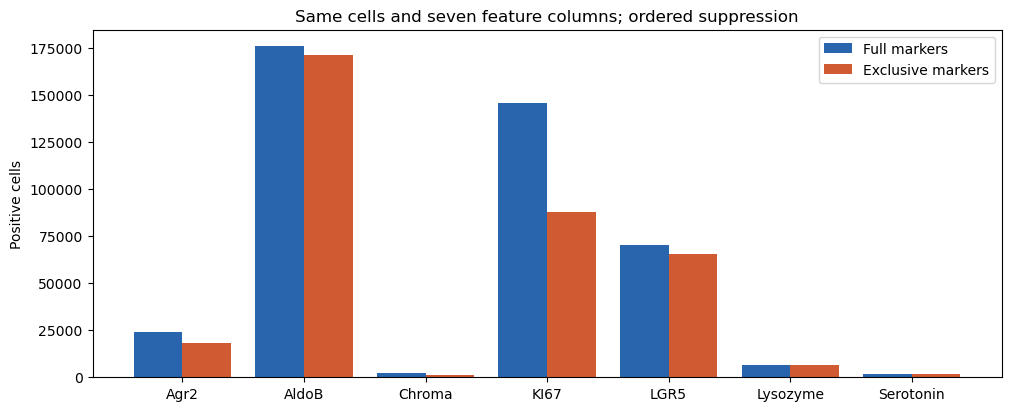

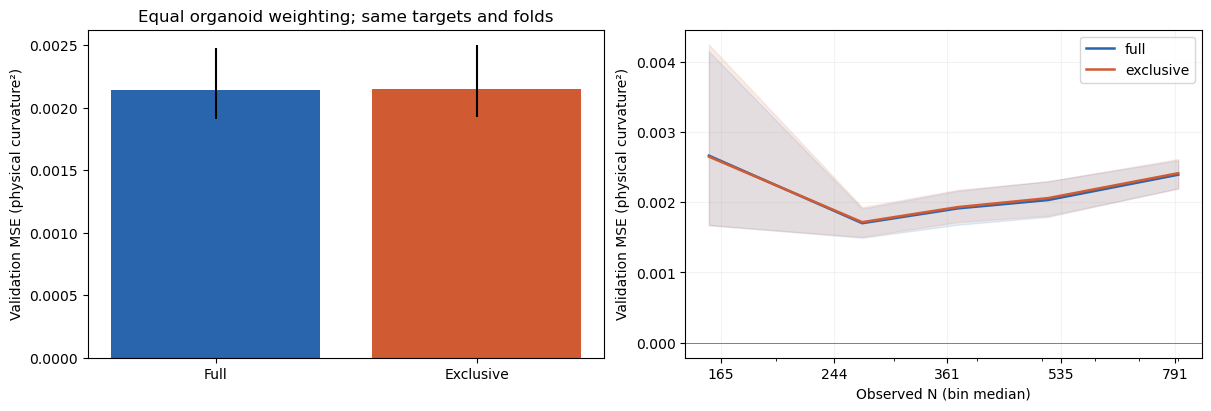

In [3]:
display(comparison_figures['01_encoding_audit'])
plt.close(comparison_figures['01_encoding_audit'])
display(comparison_figures['02_validation_mse'])
plt.close(comparison_figures['02_validation_mse'])

## Primary LGR5-recipient ablation comparison

**Blue and orange compare identical exclusive-eligible recipients and source cells.** The full model receives their original full marker vectors throughout the graph; the exclusive model receives the exclusive vectors. Recipient identities are held fixed within each ablation. Matching labels use the recipient's retained exclusive marker, so blue curves are not re-expanded across its original coexpressed markers.

The gray dotted curves reproduce the original full-marker sampling cohorts. A gray-to-blue difference reflects case eligibility, sampling and labeling changes; a blue-to-orange difference reflects the new representation and retrained model on matched cells.

The y-axis is `ΔK × Â_train-fold(N)/(4π)`, where `ΔK = after source-marker removal − intact prediction`. Negative means removal lowers predicted curvature. Observed-size curves group different organoids by actual cell count; sweeps keep each graph and case fixed while changing the FiLM and head size inputs. They are not longitudinal trajectories.

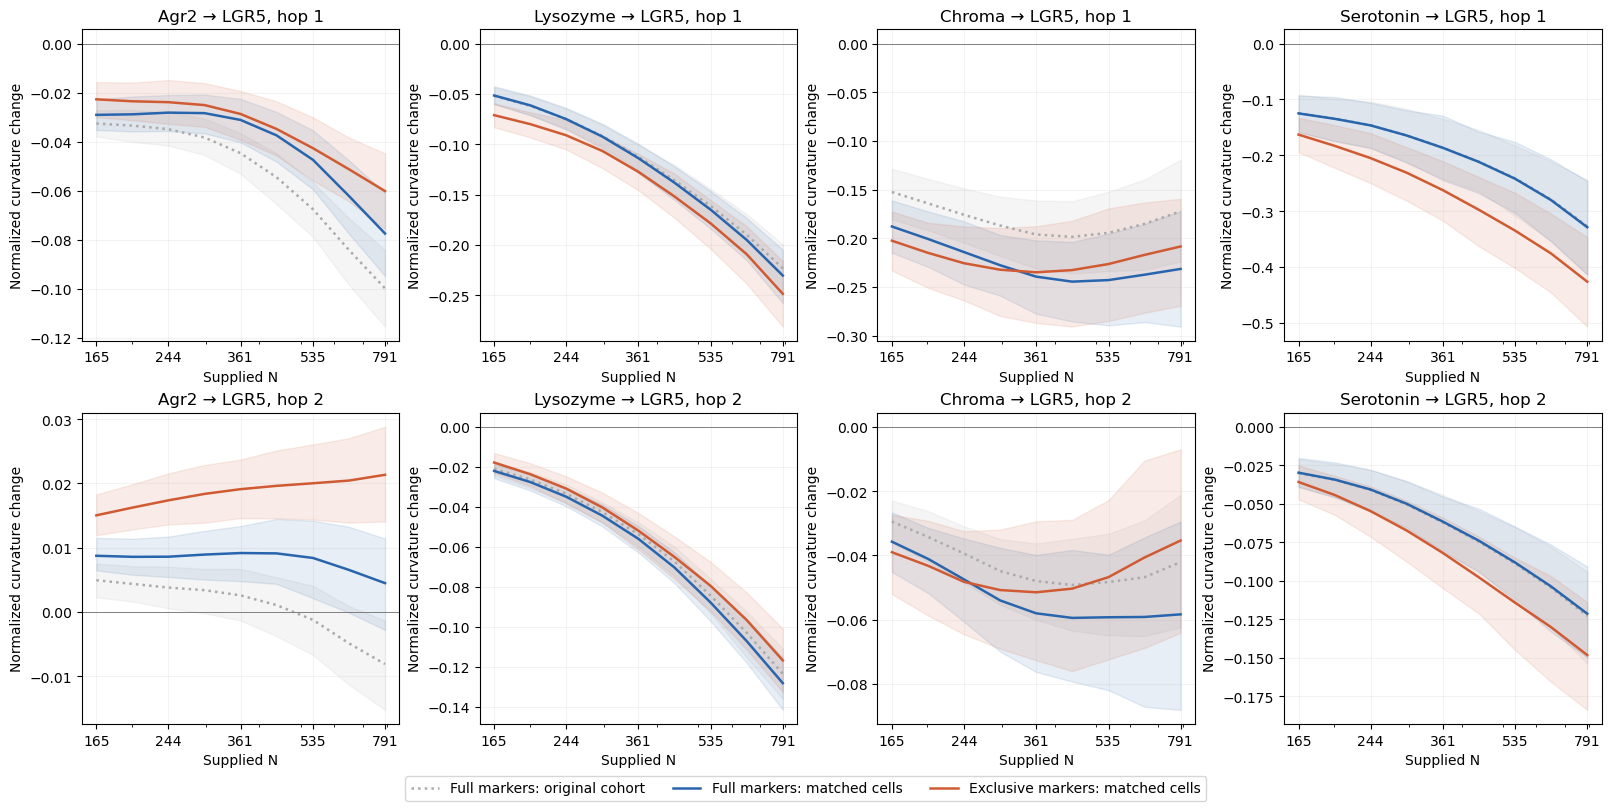

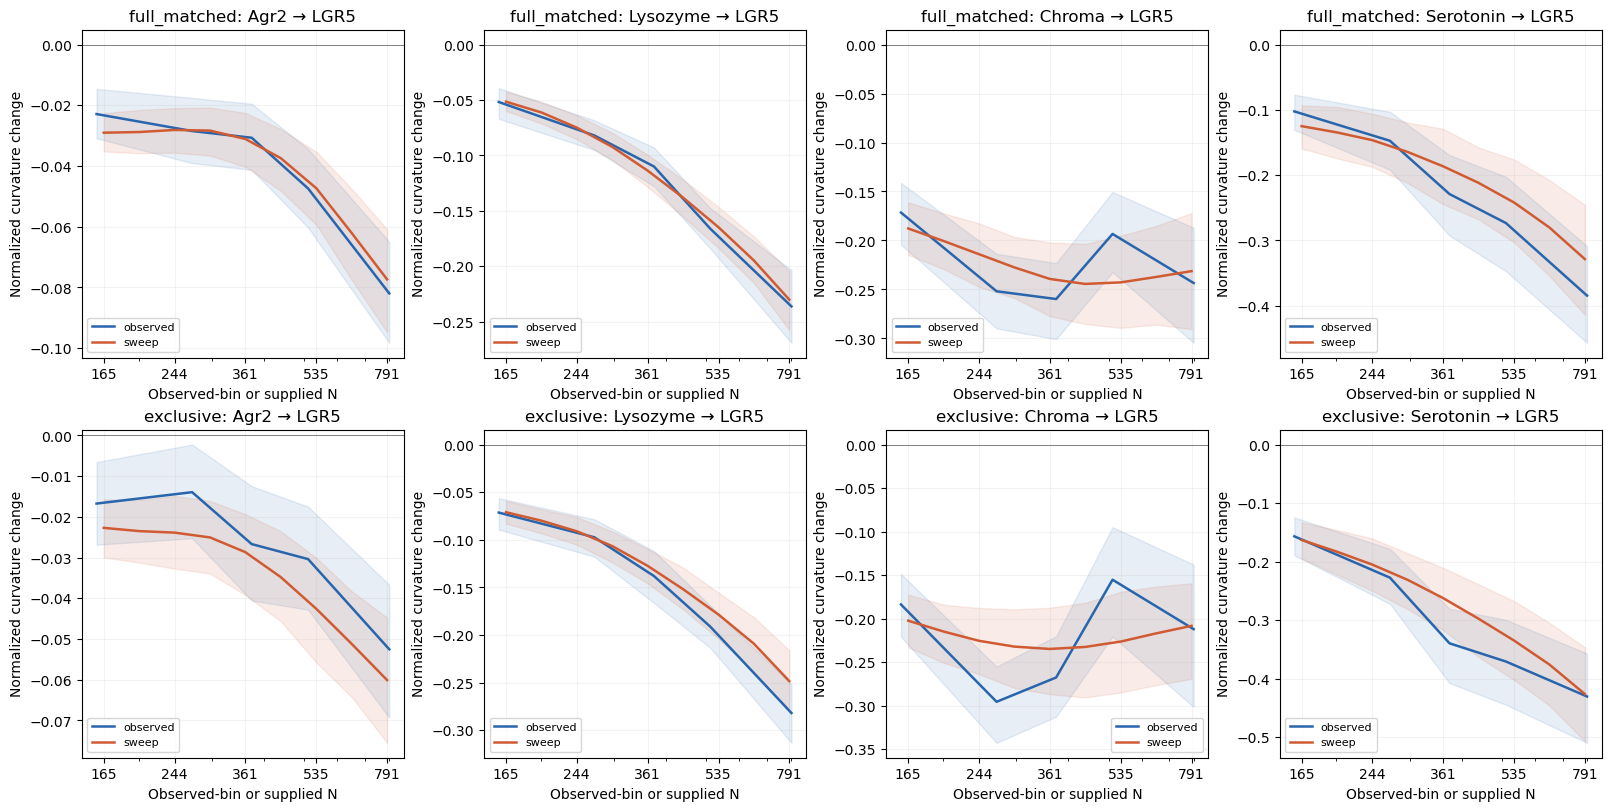

In [4]:
display(comparison_figures['04_lgr5_sweep_comparison'])
plt.close(comparison_figures['04_lgr5_sweep_comparison'])
display(comparison_figures['05_observed_and_sweep'])
plt.close(comparison_figures['05_observed_and_sweep'])

## Control for how much source fate is removed

Exclusive one-marker removal leaves the source vector all zero. Original one-marker removal may leave other positive markers behind. The green control therefore removes *all* marker bits from the same source in the original full-marker model. It preserves the recipient and all other cells. This helps assess perturbation severity; the intact graph representations and fitted models still differ.

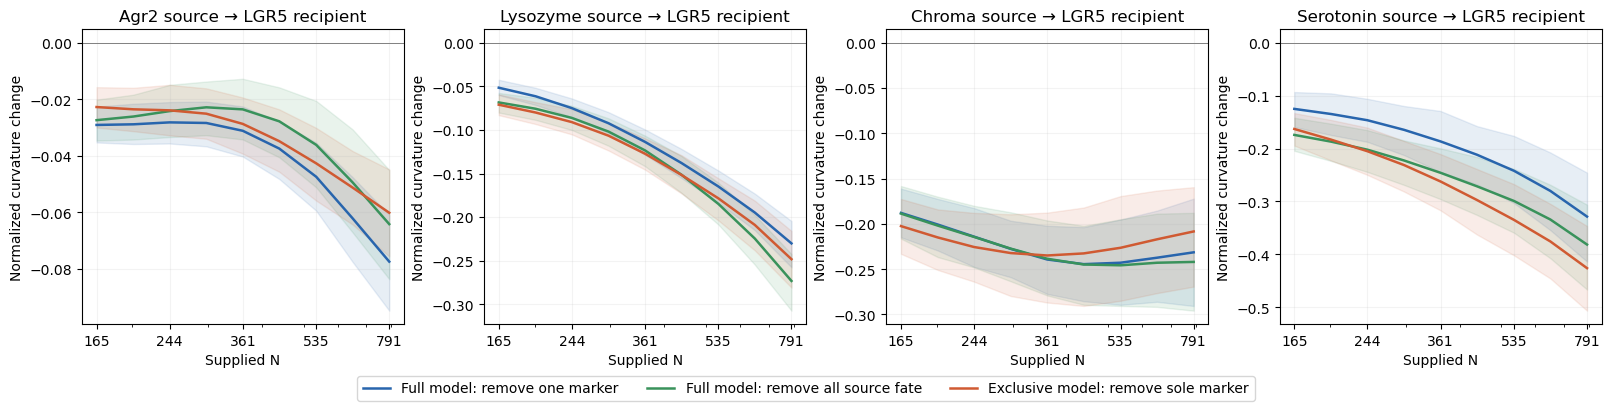

In [5]:
display(comparison_figures['05b_full_source_fate_control'])
plt.close(comparison_figures['05b_full_source_fate_control'])

## All marker pairs: size sweeps

Rows denote unchanged recipient markers, including unmarked recipients. Columns denote source markers removed at the indicated exact hop. Curves with fewer than five contributing organoids are masked. Every eligible exclusive case is paired with a full-marker evaluation on the same cells.

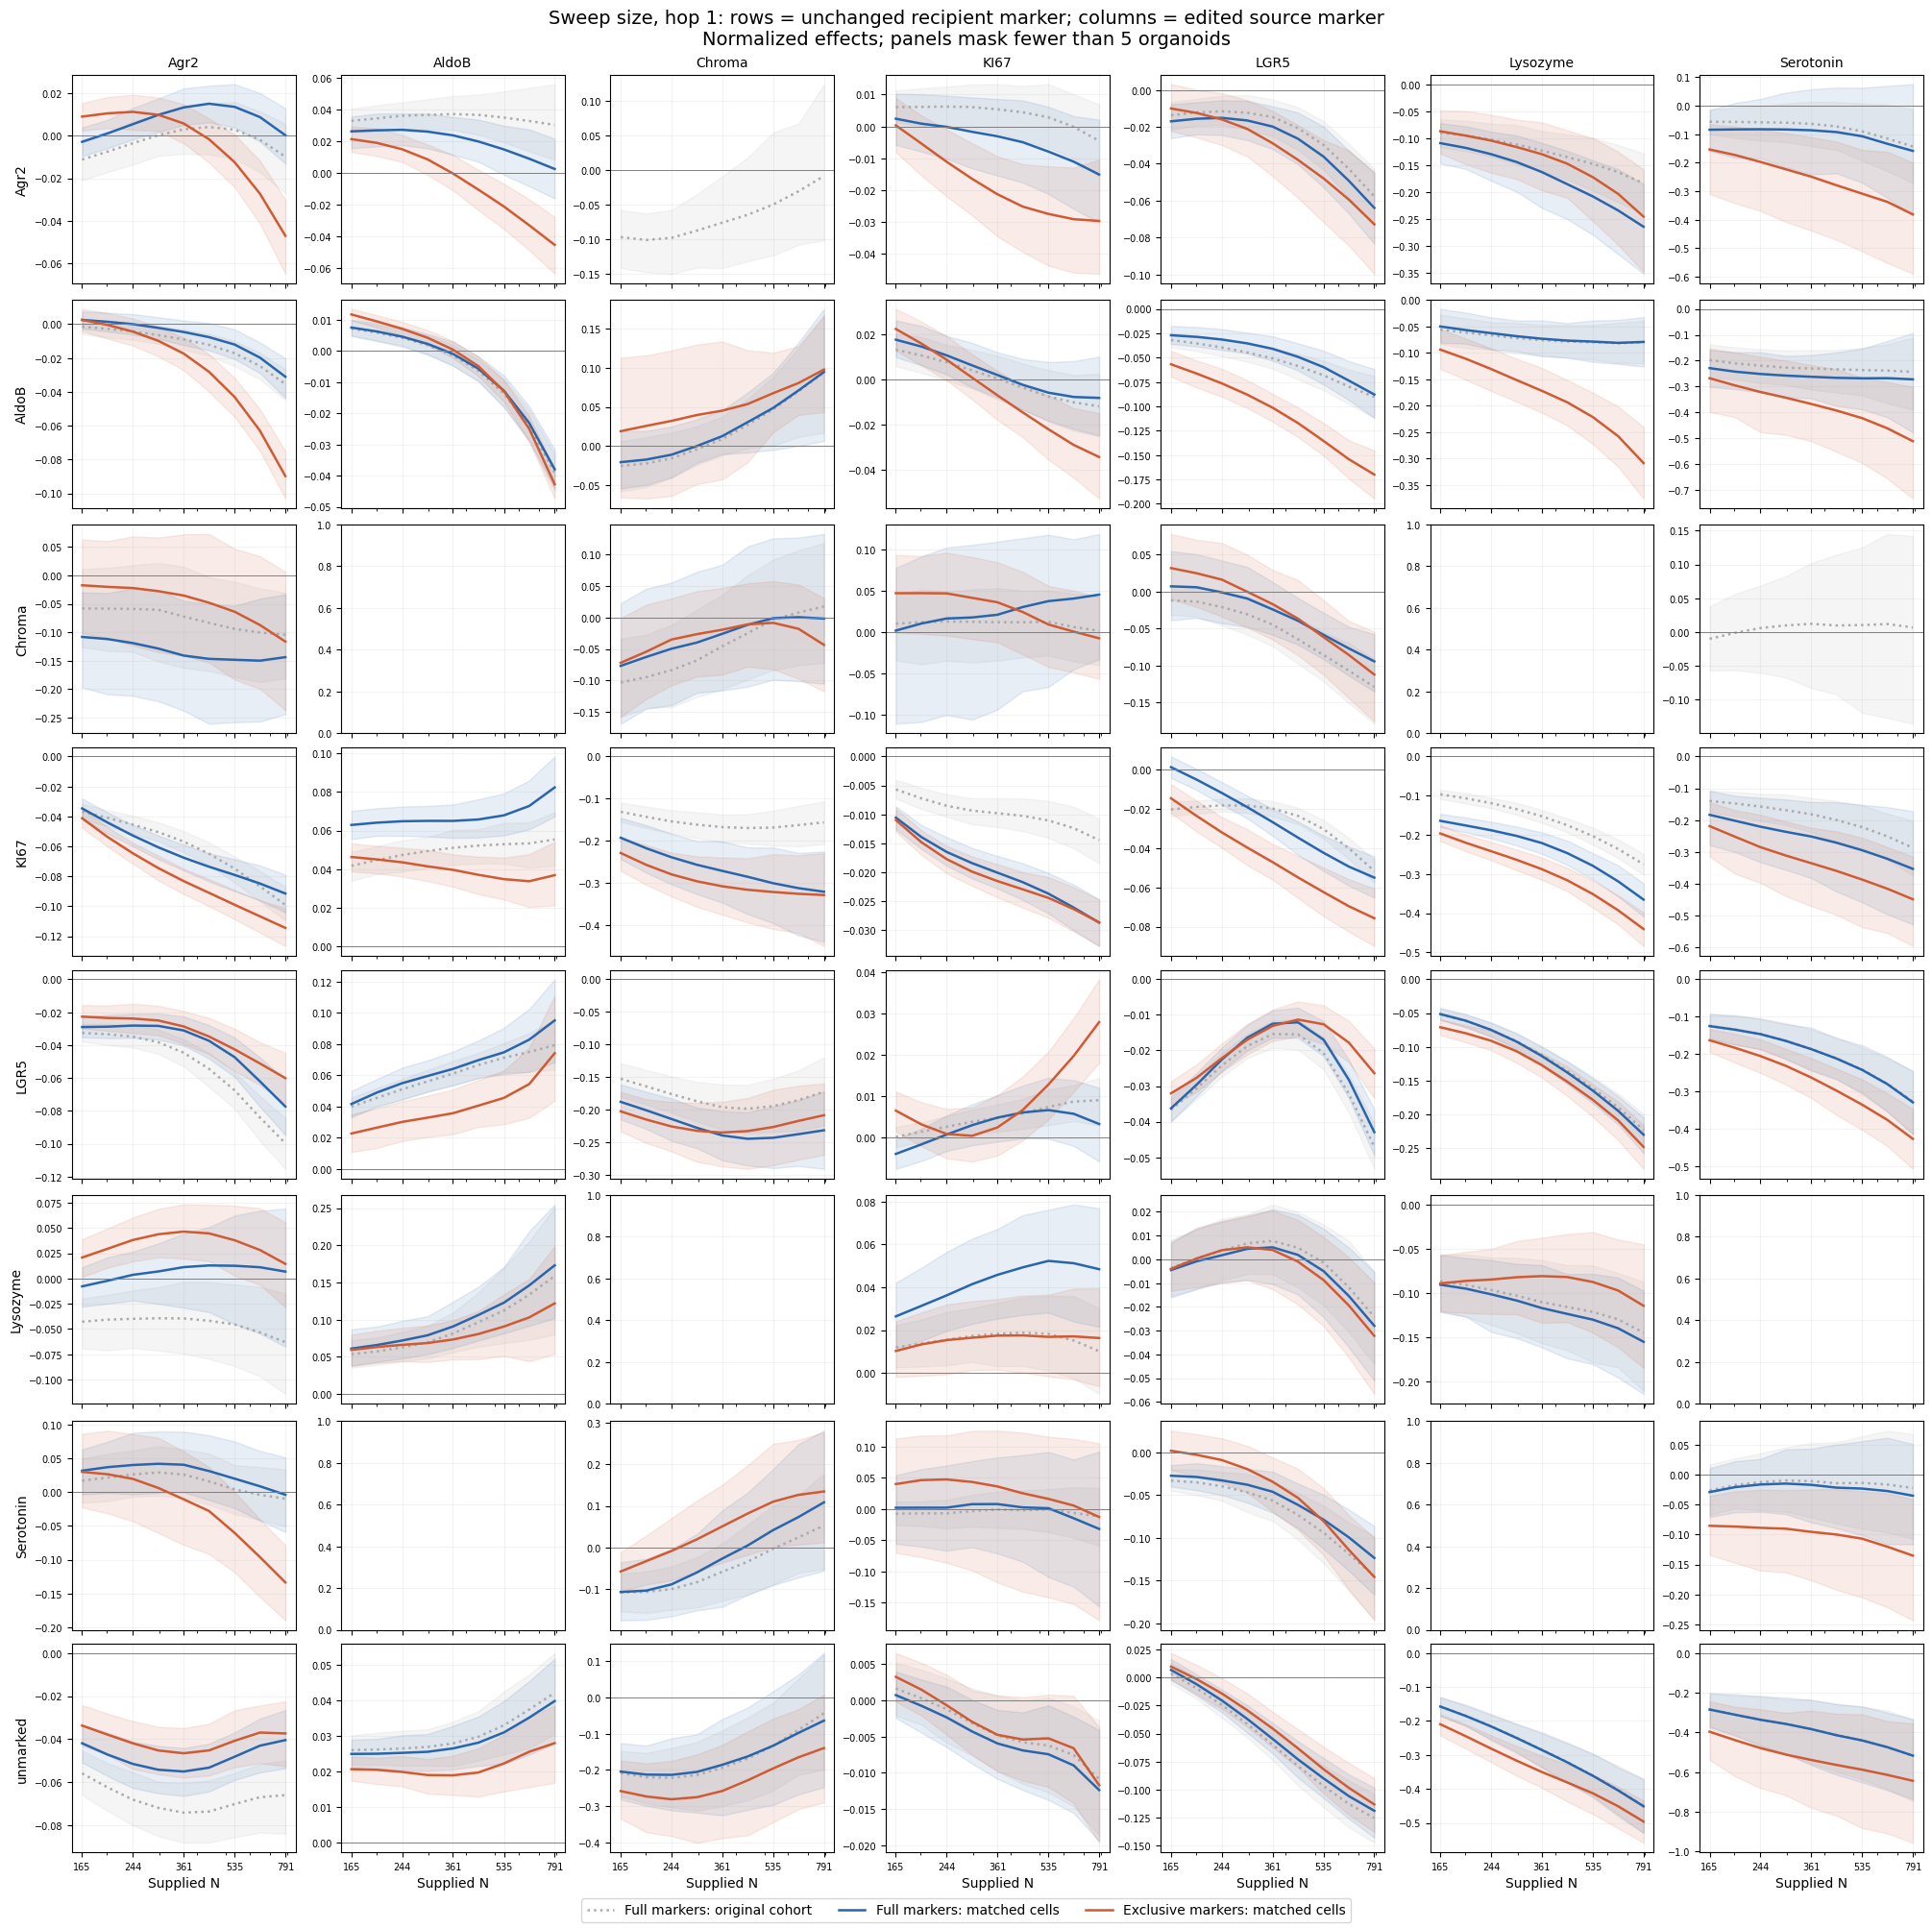

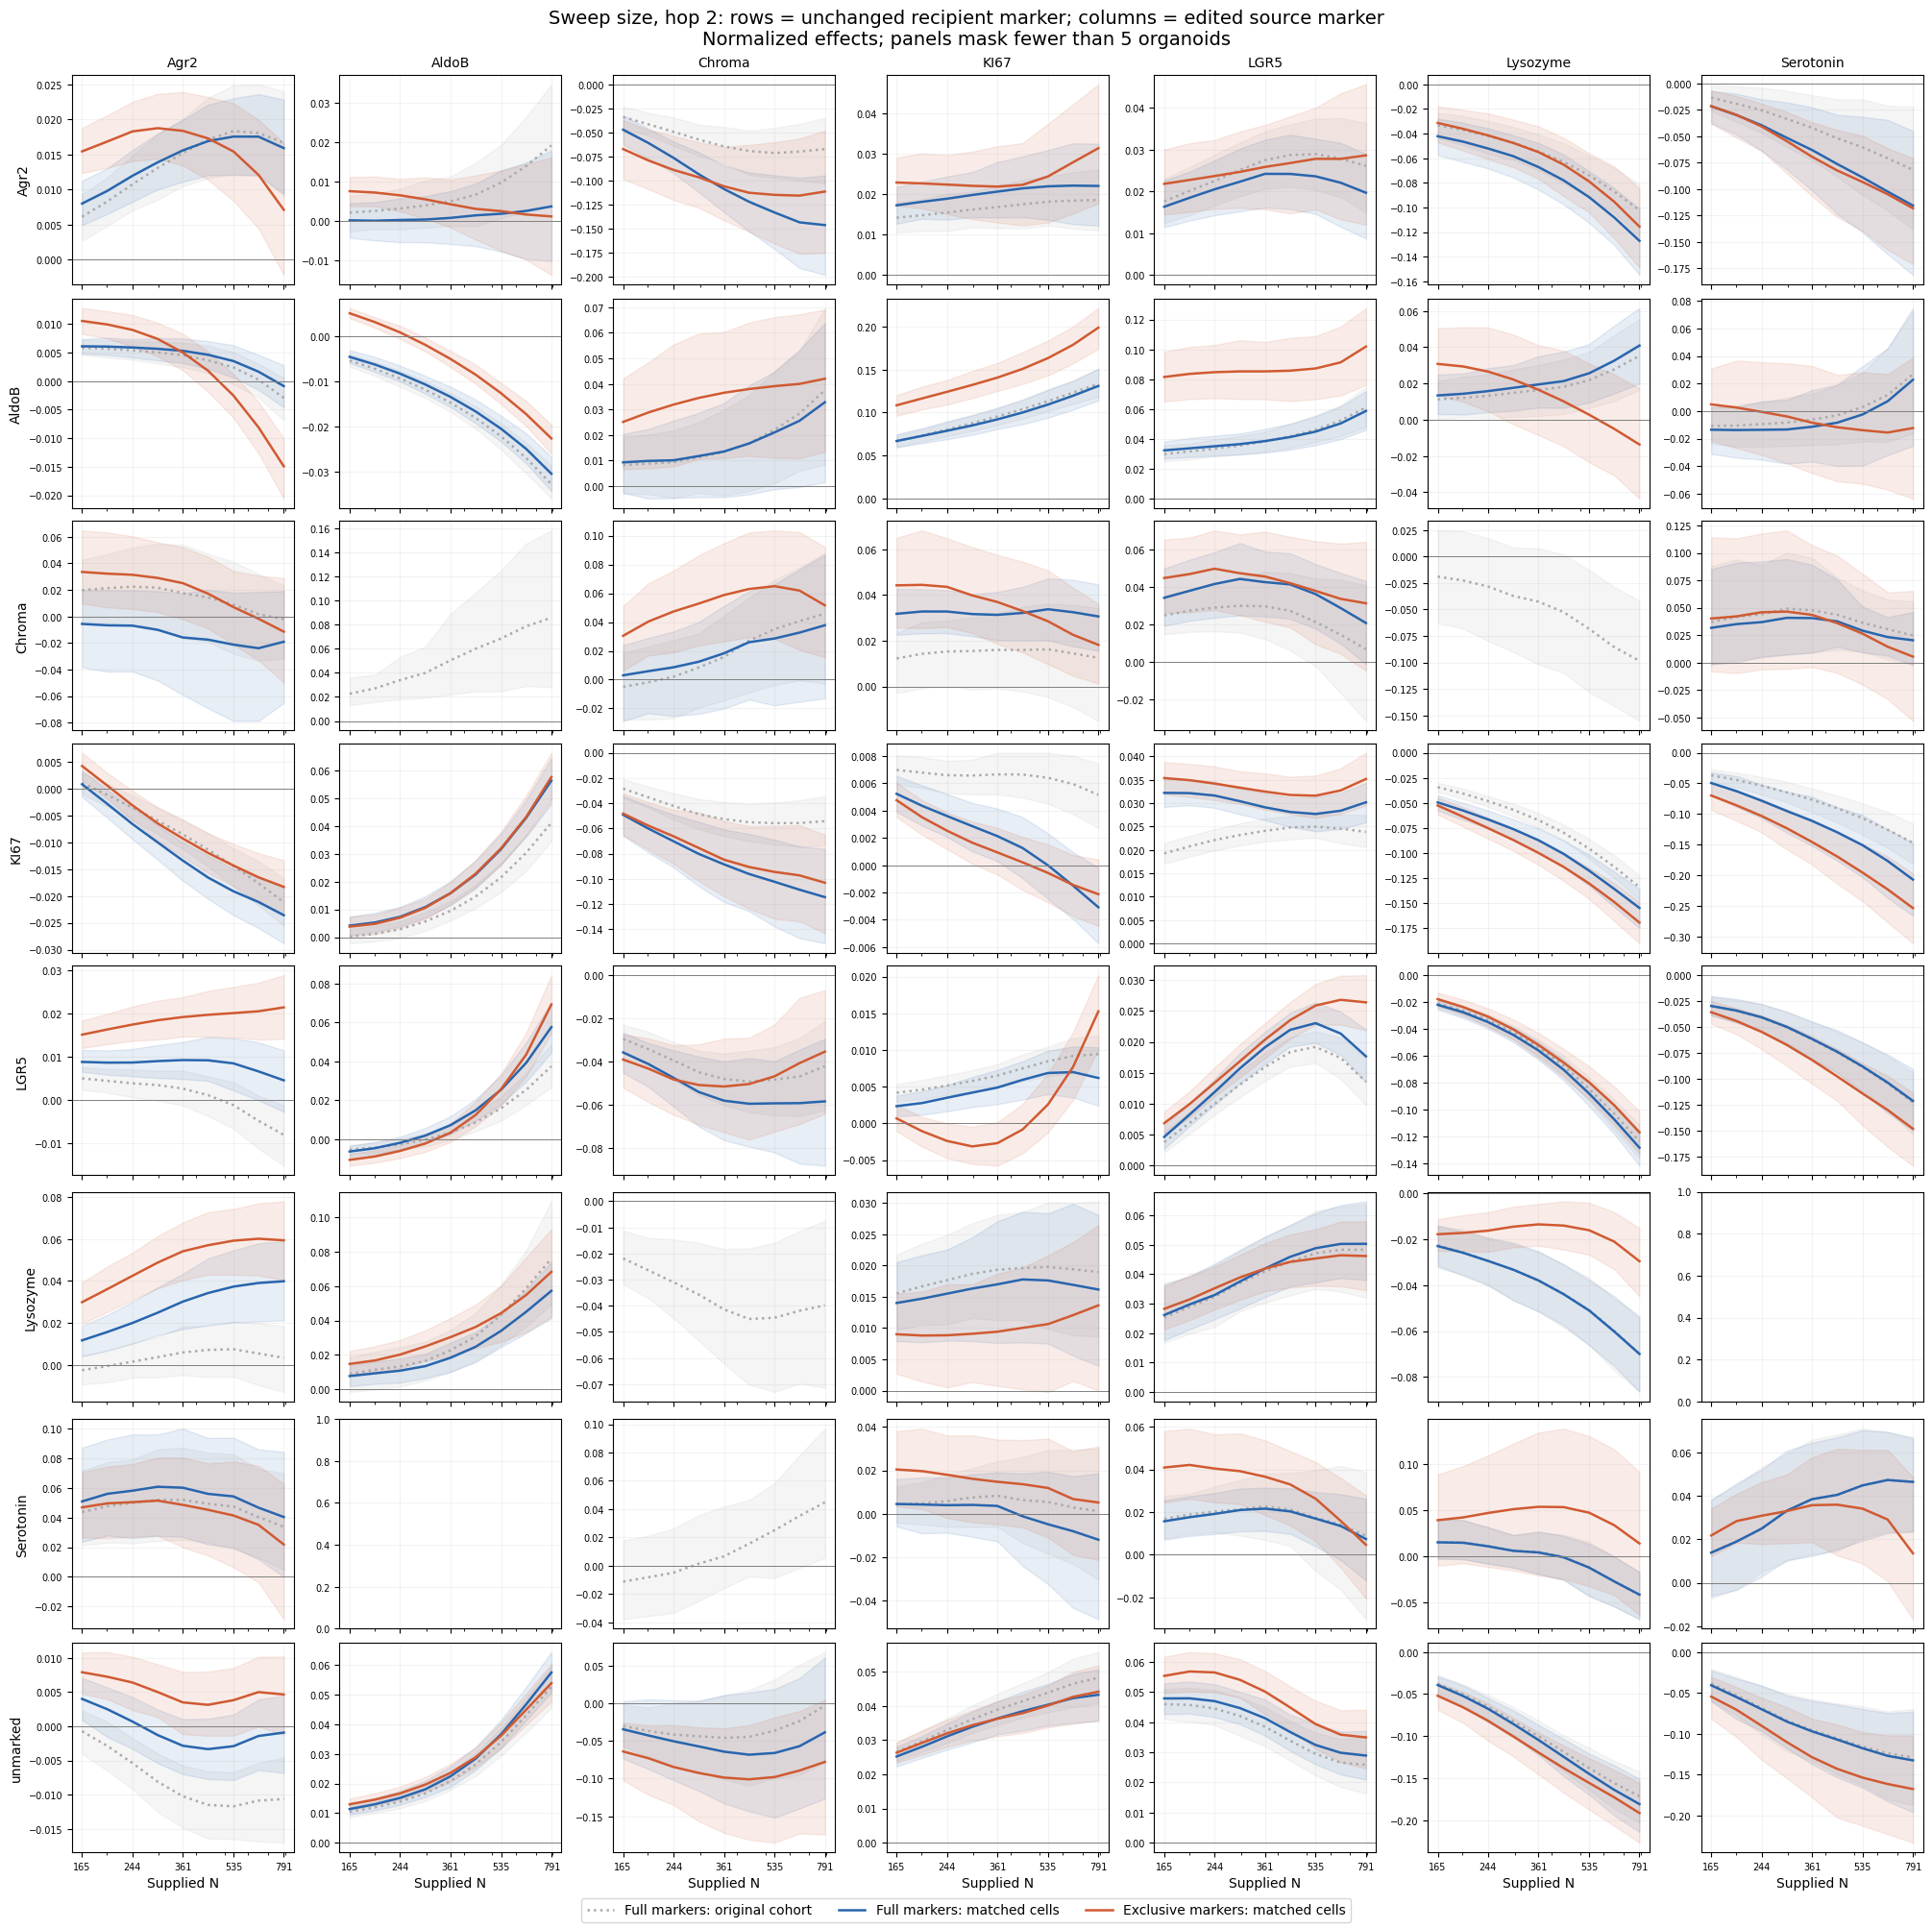

In [6]:
display(comparison_figures['03_sweep_all_markers_hop1'])
plt.close(comparison_figures['03_sweep_all_markers_hop1'])
display(comparison_figures['03_sweep_all_markers_hop2'])
plt.close(comparison_figures['03_sweep_all_markers_hop2'])

## All marker pairs: observed sizes

These curves use observed N, grouped into the same original cohort quintiles. The original full-marker curves can have different recipient/source cohorts. Confidence intervals condition on fitted models and calibration and do not include retraining uncertainty.

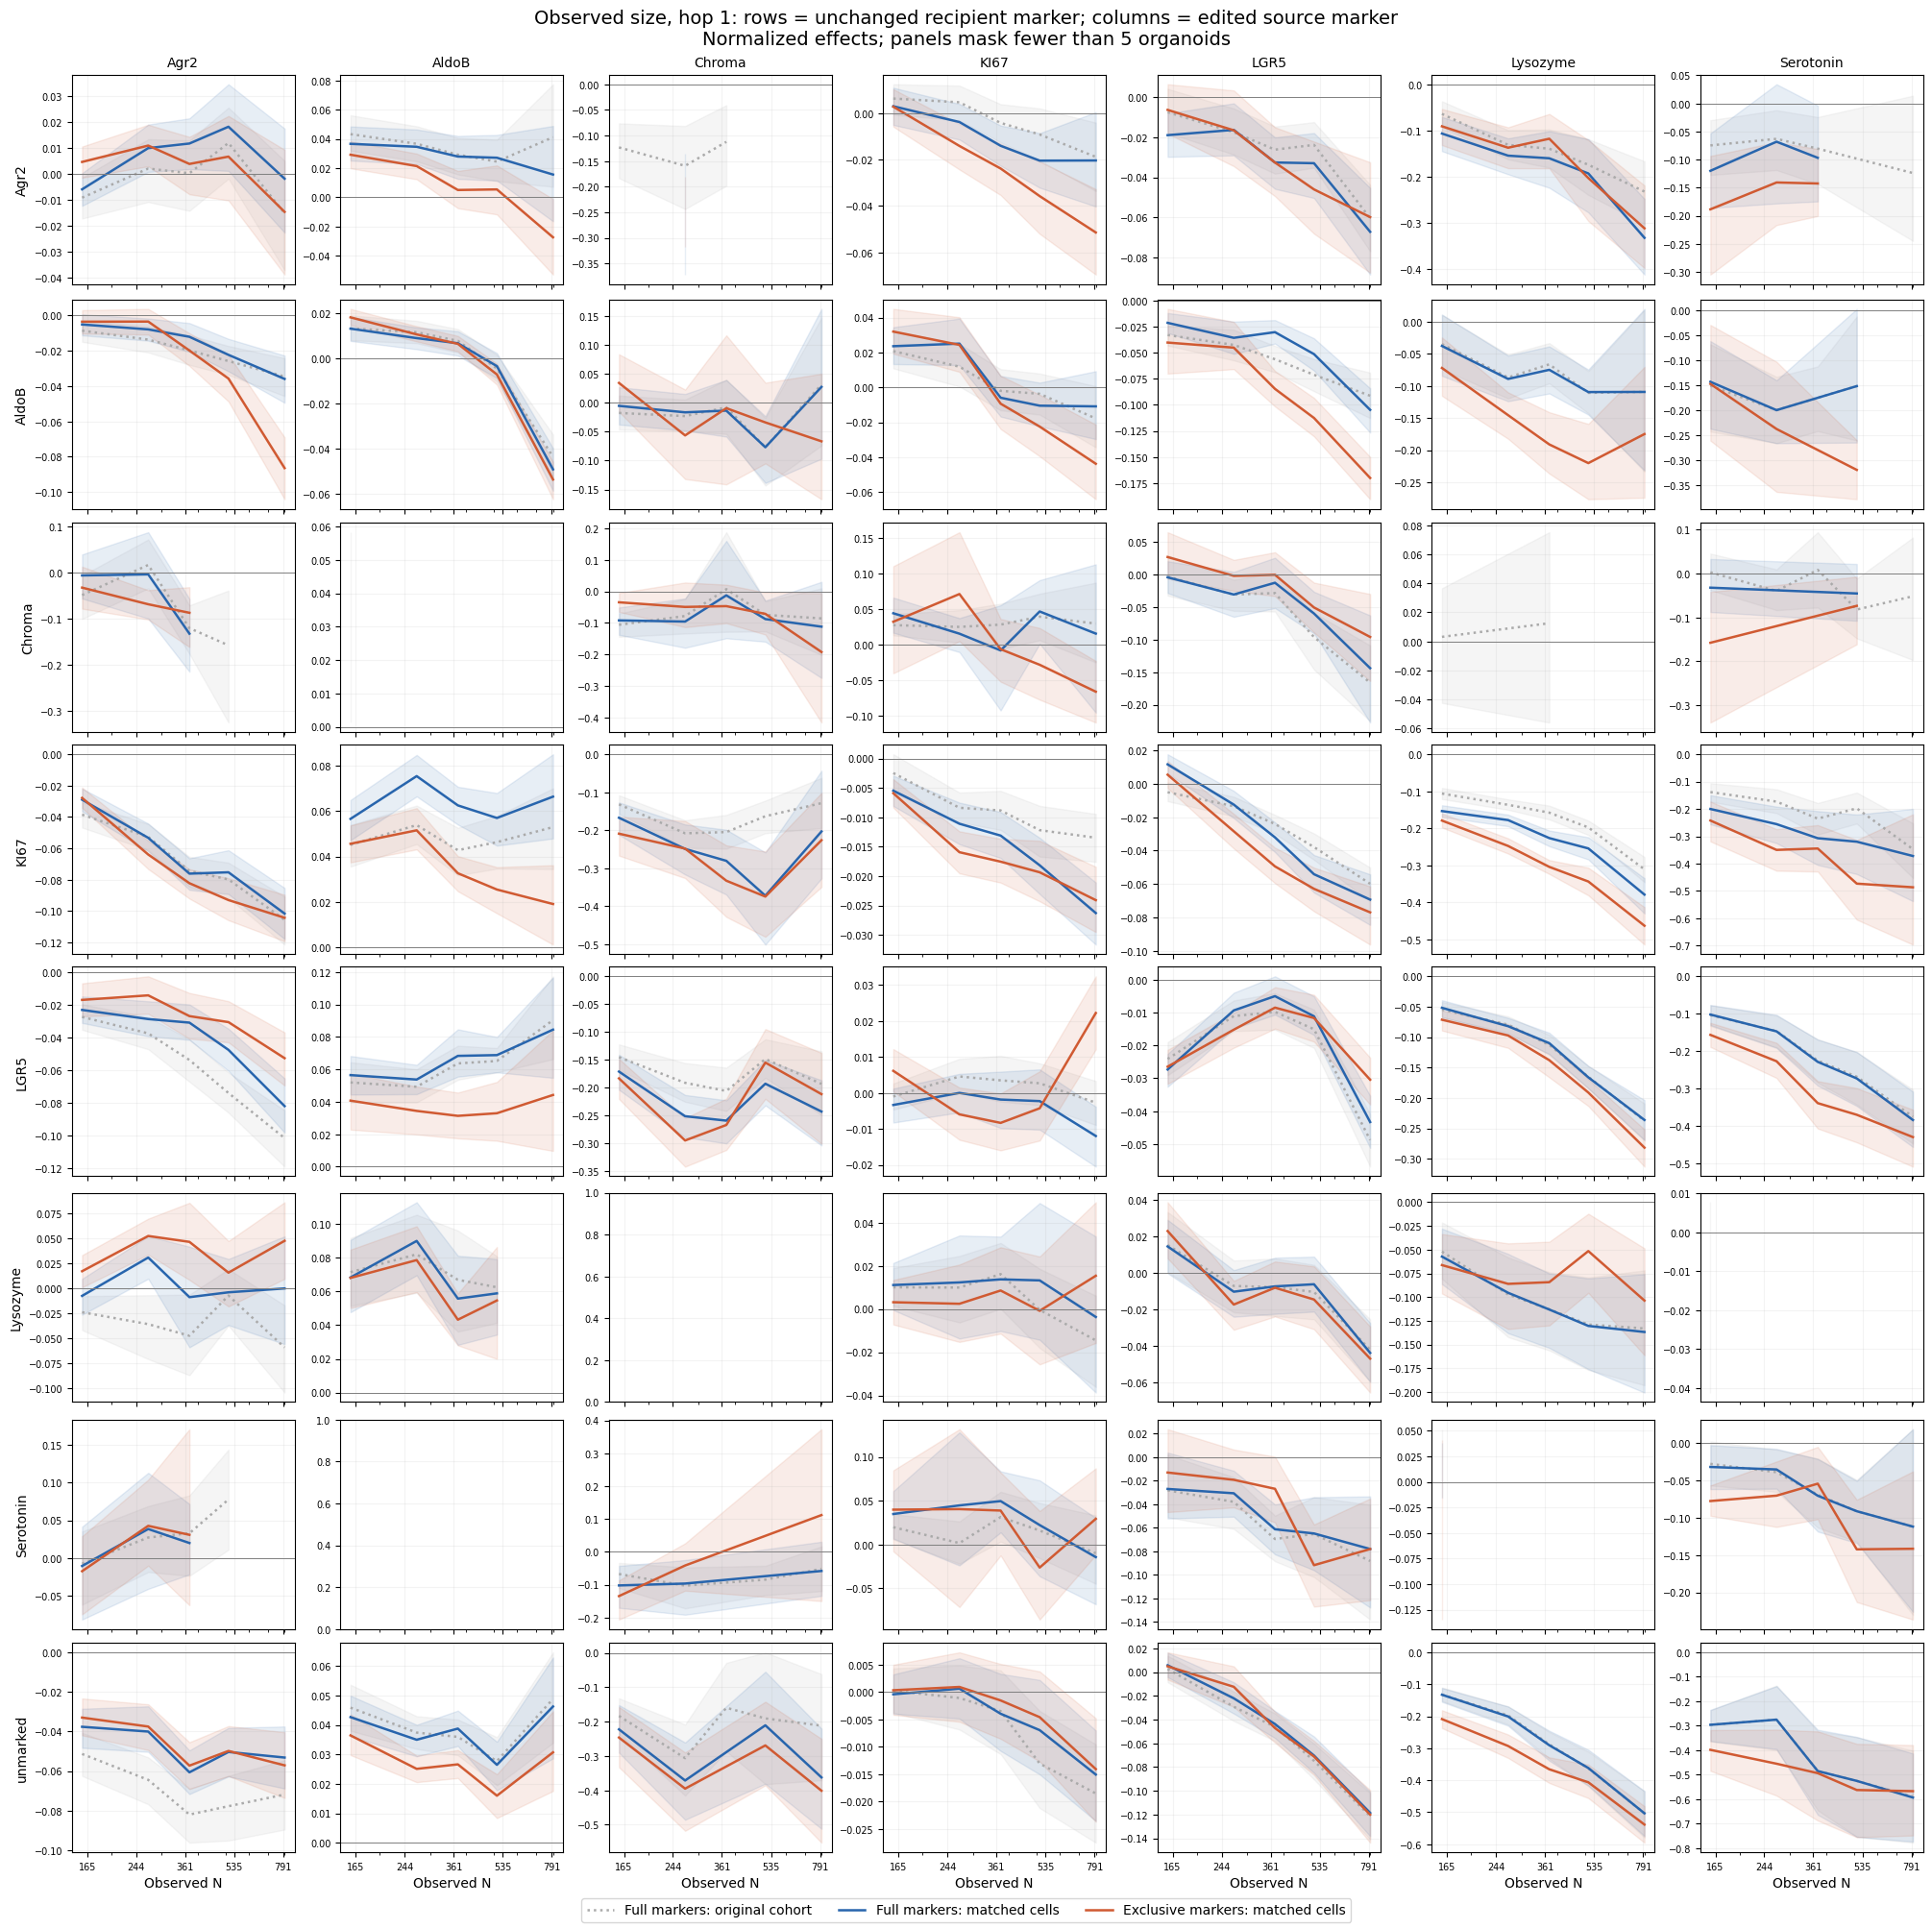

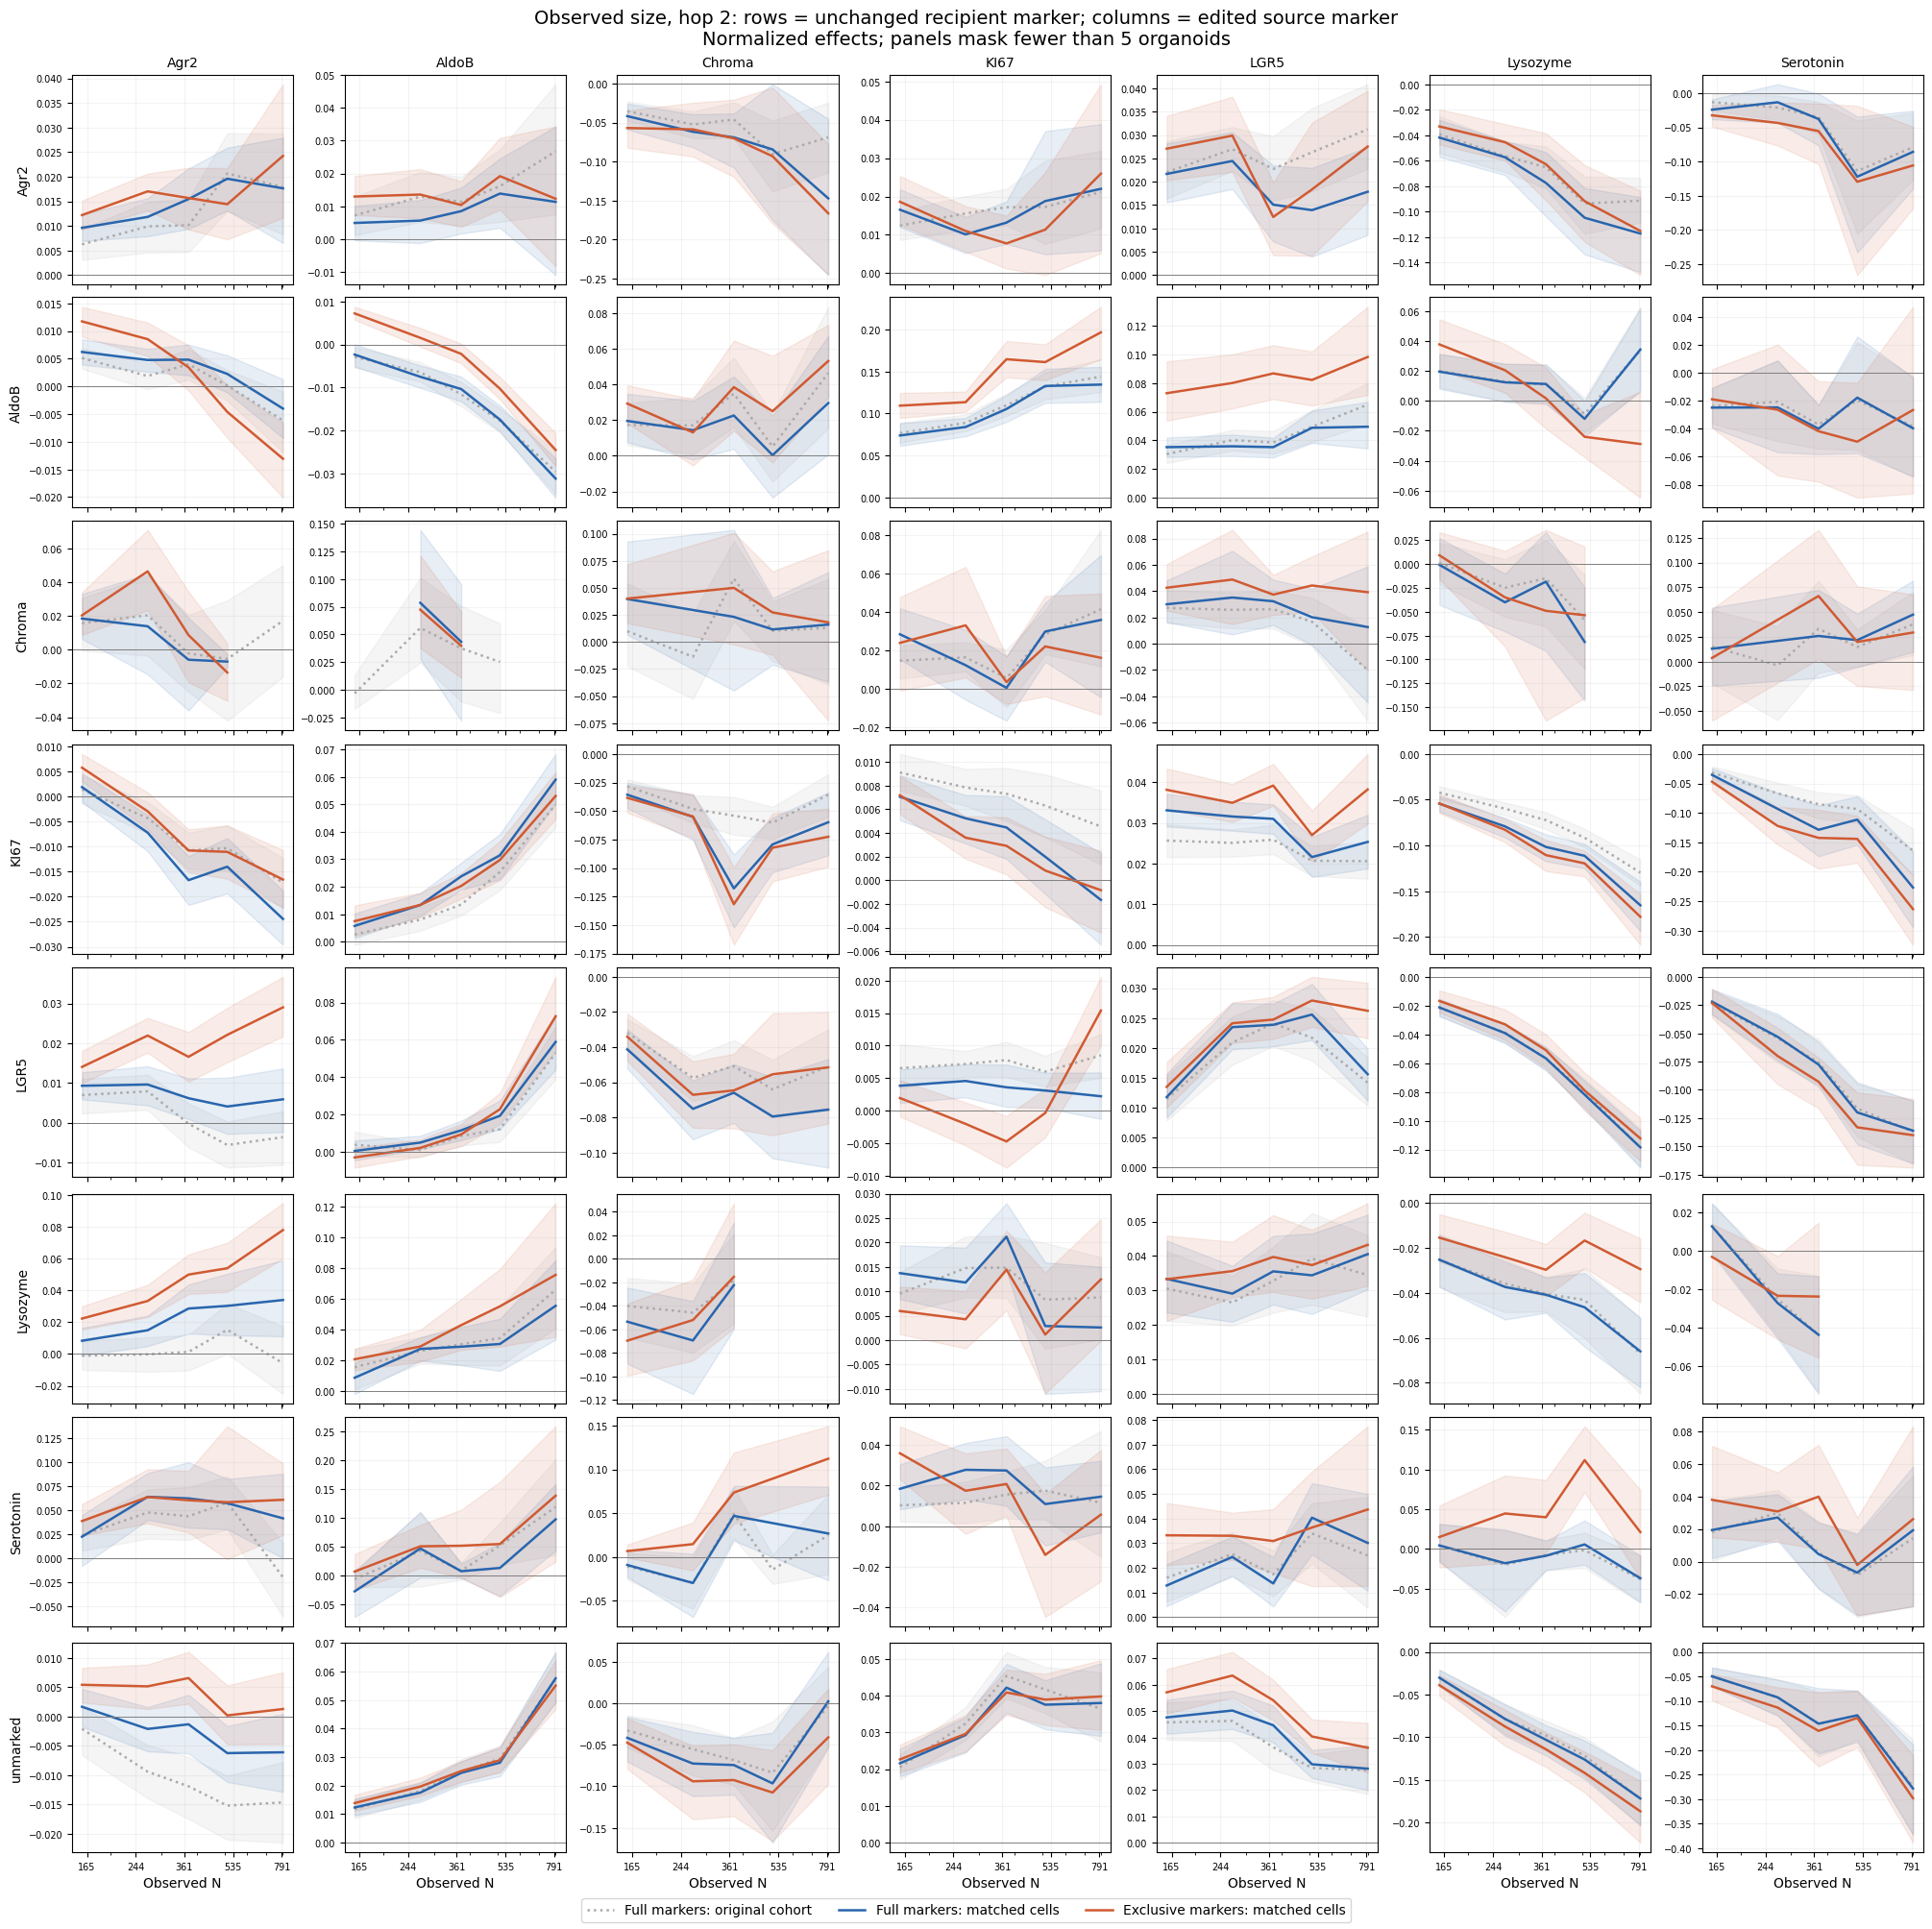

In [7]:
display(comparison_figures['03_observed_all_markers_hop1'])
plt.close(comparison_figures['03_observed_all_markers_hop1'])
display(comparison_figures['03_observed_all_markers_hop2'])
plt.close(comparison_figures['03_observed_all_markers_hop2'])

## Relative source preference around LGR5 recipients

For the same LGR5-positive recipient and hop, average absolute single-source effects within candidate source groups A and B. Their relative sensitivity is `D = (S_A − S_B)/(S_A + S_B)`. Positive favors A; negative favors B. This is not an additive share of the prediction or total abundance-weighted influence. The positive geometric factor cancels in D.

Agr2 and Chroma represent exclusive-eligible precursor-marker states; Lysozyme and Serotonin represent their retained mature markers. The full model's paired results use these same selected cells but retain their full original features. Double-positive *encoded* states disappear by construction; this does not imply biological coexpression or intermediate states are absent.

Gray curves retain the previous native-cohort result for context. Matched blue and orange comparisons are the primary encoding comparison. Transformed-target curves check dependence on the nonlinear inverse transform.

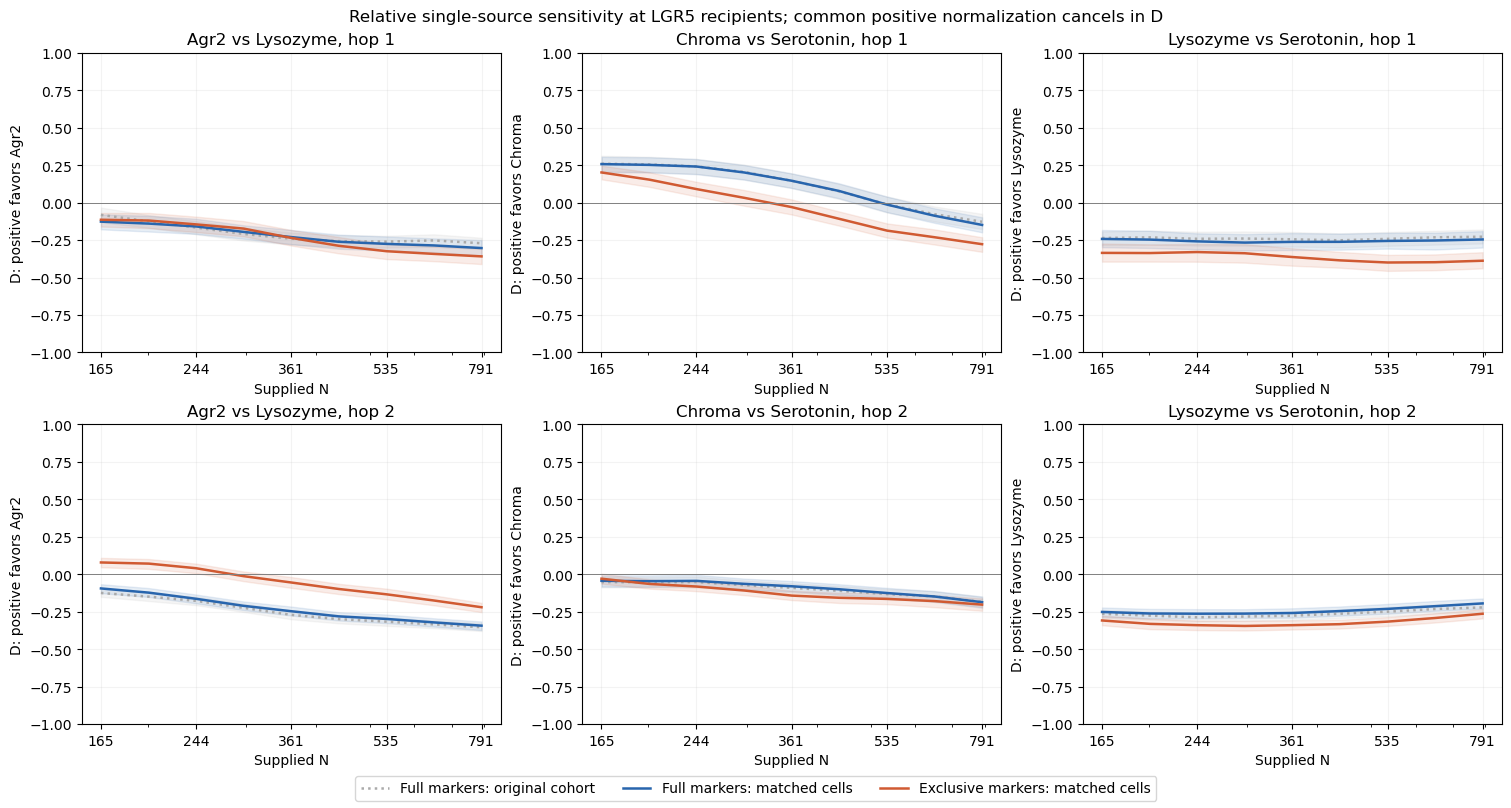

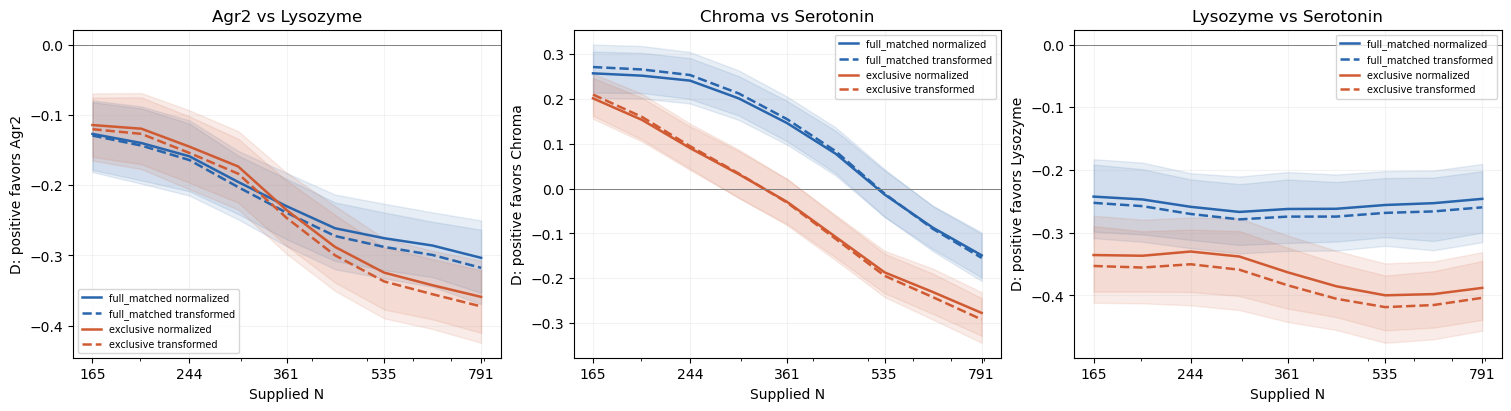

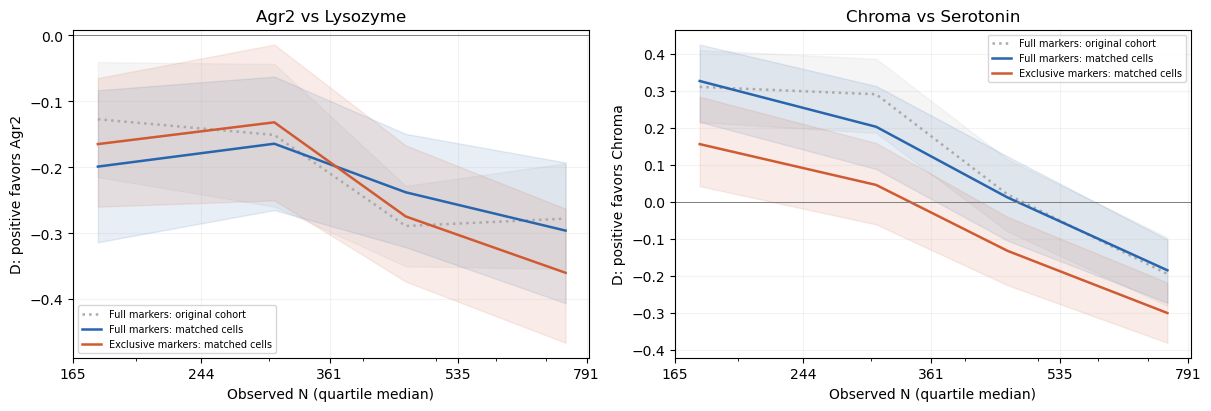

In [8]:
display(comparison_figures['06_niche_dominance'])
plt.close(comparison_figures['06_niche_dominance'])
display(comparison_figures['07_dominance_output_scale_check'])
plt.close(comparison_figures['07_dominance_output_scale_check'])
display(comparison_figures['08_observed_niche_dominance'])
plt.close(comparison_figures['08_observed_niche_dominance'])

## Redundancy, recipient specificity and detected crypt context

Lysozyme–Serotonin factorial contrasts remove markers from two distinct source cells around an unchanged LGR5 recipient: `both removed − Lysozyme removed − Serotonin removed + intact`. A negative interaction with negative individual effects is consistent with buffering in the model; it does not identify a biological signaling mechanism.

Backup-context matching uses the same source, organoid, hop, encoded recipient marker signature and crypt region, plus coarsened degree and local LGR5 fraction. The paired full evaluation uses these identical cases. Context labels here derive from the exclusive sampling representation; original additional marker bits remain visible to the full model.

Crypt labels describe observed, sufficiently mature structures. No detected crypt is not a known pre-crypt state, and the destructive snapshots cannot establish formation-to-maintenance transitions.

The green factorial control removes **all positive marker bits from each selected source cell** in the original full-marker model, using the same recipients and source pairs. This matches the all-zero source state produced by exclusive-marker removal and tests whether differences in interaction magnitude arise from the amount of fate information removed.

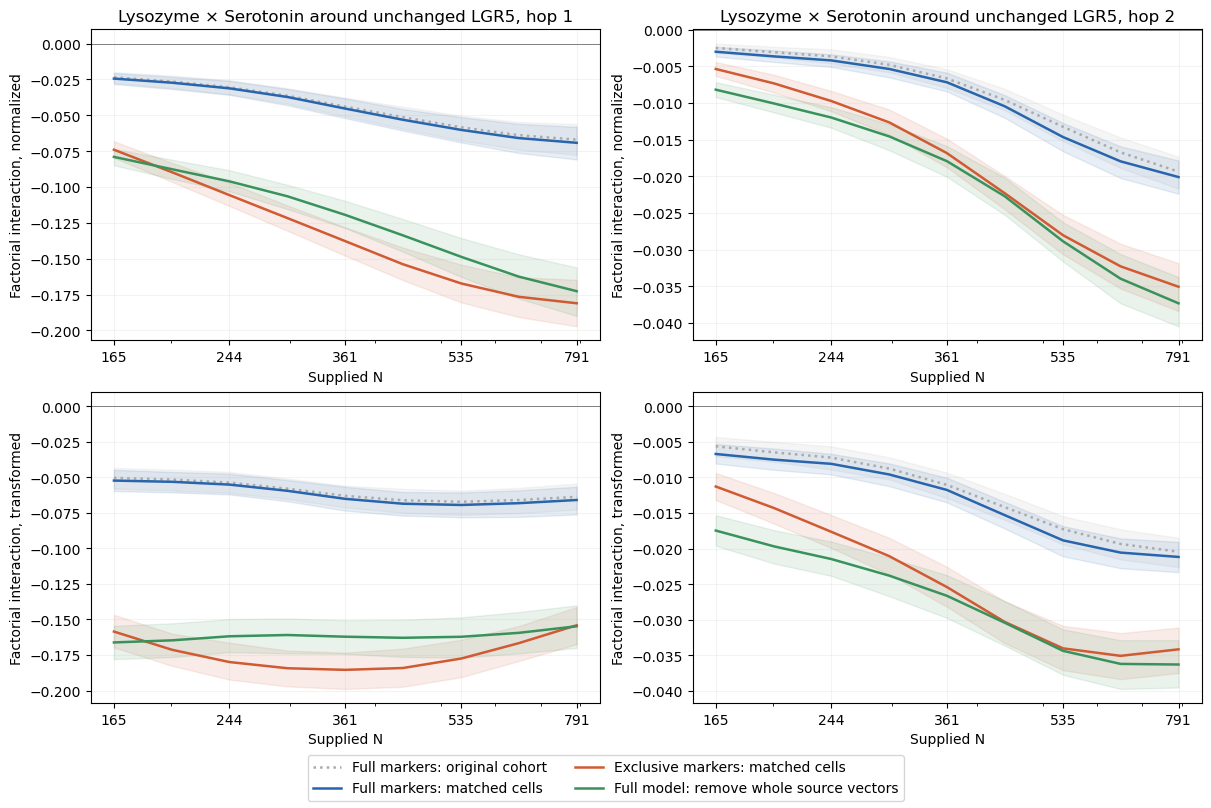

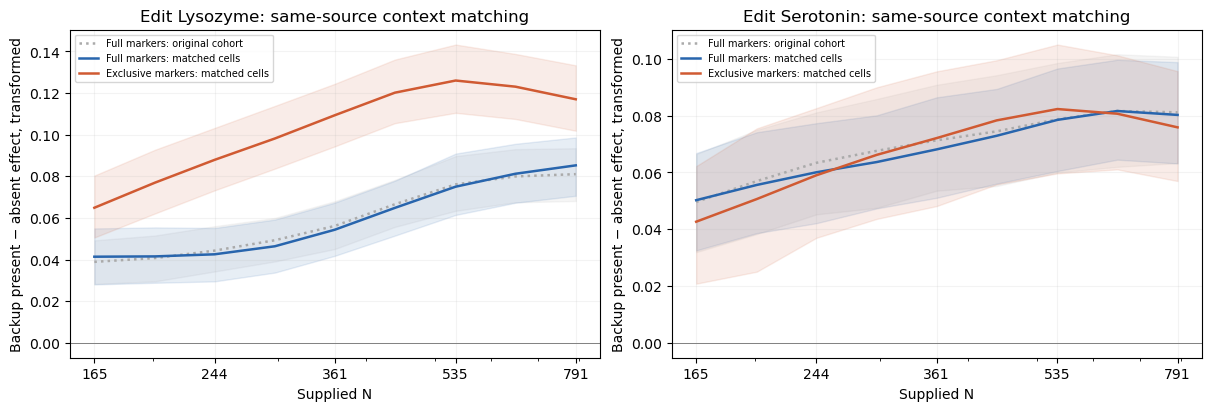

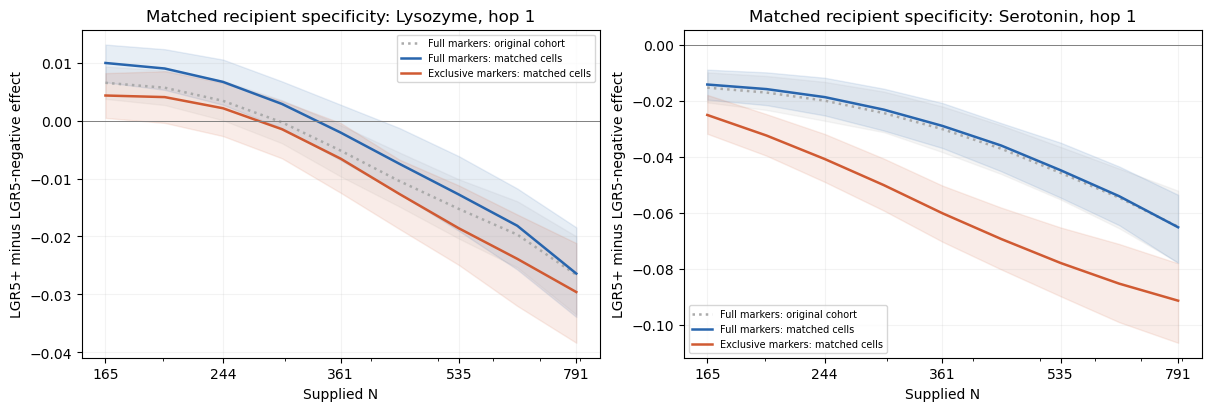

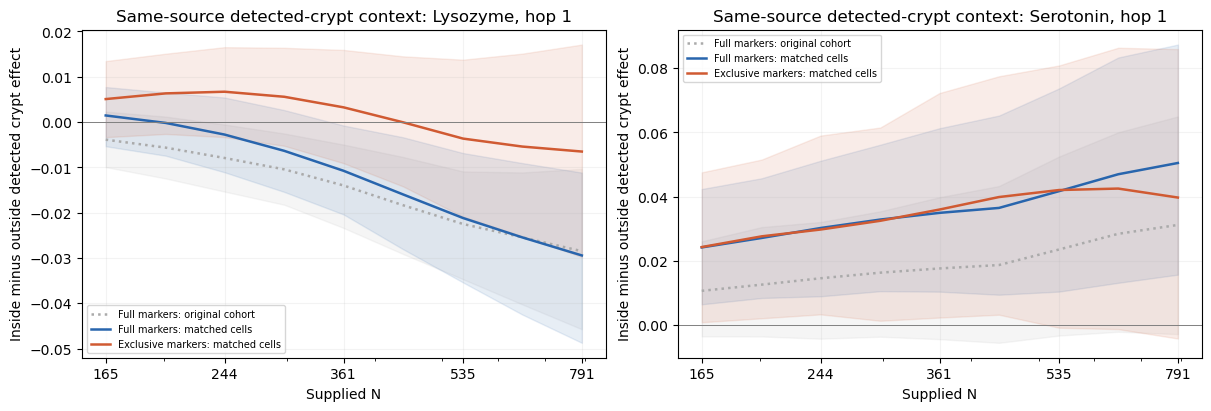

In [9]:
display(comparison_figures['09_redundancy_comparison'])
plt.close(comparison_figures['09_redundancy_comparison'])
display(comparison_figures['10_backup_context'])
plt.close(comparison_figures['10_backup_context'])
display(comparison_figures['11_specificity'])
plt.close(comparison_figures['11_specificity'])
display(comparison_figures['11_crypt_paired'])
plt.close(comparison_figures['11_crypt_paired'])

## FiLM routes and representation changes

The conditioning routes independently sweep both FiLM and head inputs, FiLM alone, head alone, or one FiLM layer, anchored at N=361. These interventions need not add linearly.

Hidden cosine similarities compare each model's own ablation response to its own direction at N=361. Hidden axes are not aligned between independently trained models. The common-gain diagnostic asks whether a marker-pair response vector across N can be explained by a shared positive multiplier of its N=361 vector; the unexplained norm fraction is not an explained-variance statistic.

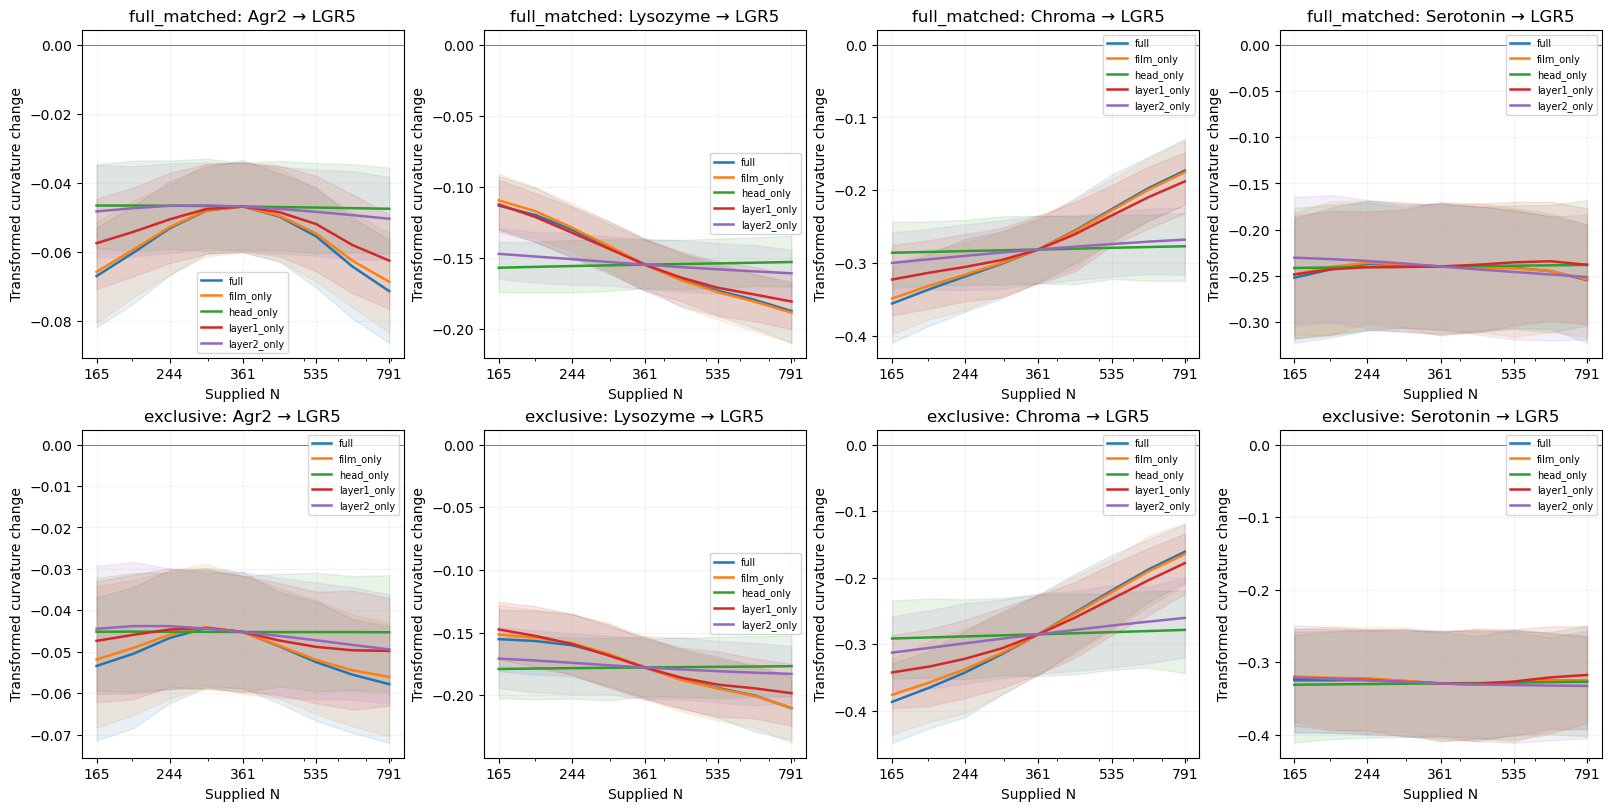

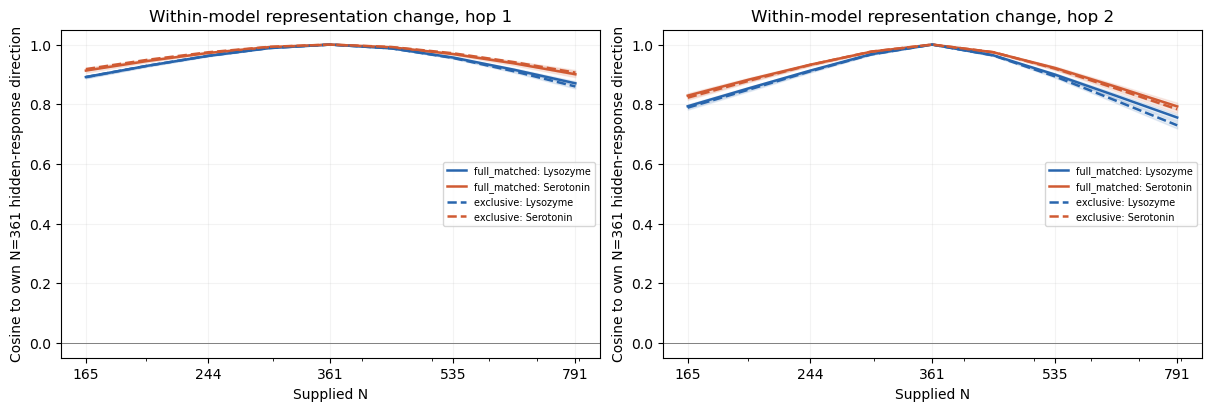

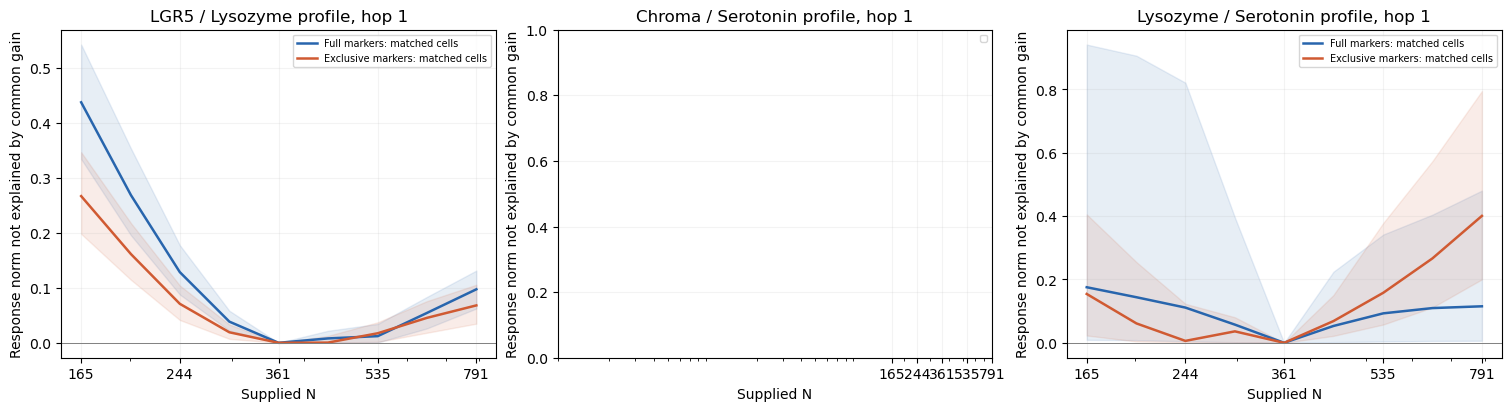

In [10]:
display(comparison_figures['12_conditioning_routes'])
plt.close(comparison_figures['12_conditioning_routes'])
display(comparison_figures['13_hidden_direction'])
plt.close(comparison_figures['13_hidden_direction'])
display(comparison_figures['14_common_scaling_check'])
plt.close(comparison_figures['14_common_scaling_check'])

## Secondary center-removal diagnostic

This supplementary factorial experiment removes center LGR5 as well as a neighboring marker. It changes recipient identity and is therefore more delicate than the primary experiments above. In the exclusive model it erases the center's entire encoded fate, while the original full model may retain other center markers. Interpret these comparisons accordingly.

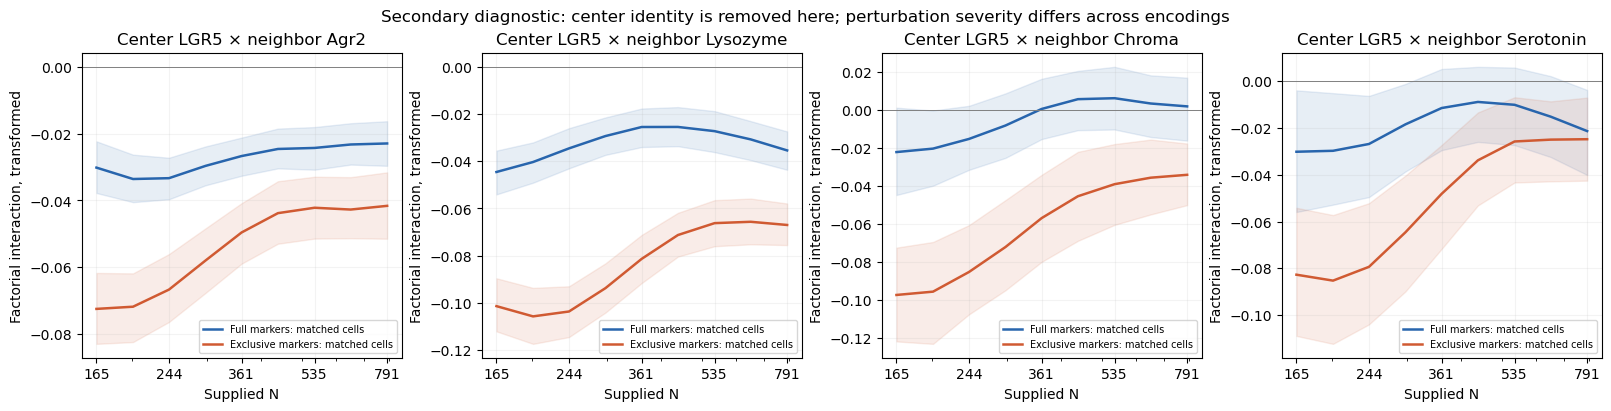

In [11]:
display(comparison_figures['15_center_removal_secondary'])
plt.close(comparison_figures['15_center_removal_secondary'])

## Findings and validation

The report below summarizes the completed comparison. Case-level data, matched support, paired endpoint contrasts and seed summaries are saved in the result directory.

In [12]:
display(Markdown((COMPARISON_DIR / 'REPORT.md').read_text()))
display(pd.Series(json.loads((COMPARISON_DIR / 'validation.json').read_text()), name='Validation checks'))

# Full versus exclusive fate markers: size-conditioned FiLM

**The Chroma-to-Serotonin preference shift survives exclusive encoding in all three seeds. Validation accuracy is nearly unchanged. Apparent increases in Lysozyme–Serotonin interaction strength are largely reproduced by removing whole source-cell fate vectors in the original model, highlighting the importance of matching the perturbation itself.**

The completed comparison is displayed in `experiments/exclusive_size_conditioned_ablation.ipynb`. All figures are also saved as PNG/PDF in `figures/`. The original notebook, data and full-marker checkpoints were preserved.

## Encoding and comparison design

The supplied rules were applied **sequentially to the updated feature matrix**: clear the named marker if any currently positive exclusion exists, then proceed to the next rule. Absent markers were ignored. For example, Agr2+/Lysozyme+ becomes Lysozyme+, Chroma+/Serotonin+ becomes Serotonin+, and KI67+/LGR5+ becomes LGR5+.

The original seven binary columns and their order were retained, with no added “unassigned” feature or embedding. This keeps the architecture and parameter count identical. Across **477,789 cells in 1,100 organoids**, 68,247 multi-positive cells became single-positive. All 125,148 originally unmarked cells remain unmarked. Every possible binary combination of the seven dataset markers, and of all nine rule keys, was checked.

| Marker | Full positive cells | Exclusive positive cells |
| --- | ---: | ---: |
| Agr2 | 23,953 | 18,274 |
| AldoB | 175,787 | 171,271 |
| Chroma | 2,035 | 1,469 |
| KI67 | 145,483 | 87,898 |
| LGR5 | 70,360 | 65,609 |
| Lysozyme | 6,373 | 6,341 |
| Serotonin | 1,779 | 1,779 |

The **15 exclusive FiLM models** use the original five folds, seeds 42–44, depth 2, hidden width 256, FiLM width 16, learning rate 0.0003, batch size 128, maximum 500 epochs and patience 30. Training required 2,165 epochs in total. Only log N enters FiLM and the head; **no geometry features enter the head**. The original size-plus-geometry baseline, residual transform and training-fold geometric calibration were reused, keeping the prediction targets fixed.

Blue and orange curves compare **identical exclusive-eligible recipients and source cells**. Blue uses their full original vectors and the original trained model; orange uses exclusive vectors and the retrained model. Gray curves retain the original full-marker sampling cohorts, so gray-to-blue changes reveal eligibility, sampling and labeling effects. The paired full curves use the surviving exclusive recipient label, rather than expanding the same recipient across its original coexpressed labels.

The standard analysis includes **109,455 observed-size cases and 18,072 fixed sweep cases**, each evaluated across three seeds. The larger niche analysis uses **143,348 source–recipient cases and 2,400 distinct-source factorial cases**, with identical manifests for the two encodings. Sweeps use N=165–791 at the original nine grid points; observed-size analyses use actual N.

## 1. Predictive accuracy remains comparable

Equal-organoid-weight validation MSE is:

| Encoding | Physical-curvature MSE |
| --- | ---: |
| Full markers | 0.00213749 |
| Exclusive markers | 0.00215100 |

The increase is **0.63%**, with a paired absolute difference of 0.0000135 [conditional 95% CI 0.00000601–0.0000204]. This is a small predictive cost. The original full-model validation predictions were reproduced for every fold and seed, checking the shared preprocessing.

Sources: `comparison_tables/mse_*.csv`; figure 02.

## 2. The Chroma–Serotonin preference shift is robust, but its location changes

For each matched LGR5 recipient and exact hop, let S_A and S_B be the mean absolute single-source effects for candidate groups A and B. We compare

`D = (S_A − S_B)/(S_A + S_B)`.

Positive D favors A; negative favors B. This is a **relative per-cell sensitivity**, not an additive fraction of predicted curvature or an abundance-weighted niche contribution. The positive geometric multiplier cancels in D; transformed-target versions provide a further check on the nonlinear inverse transform.

At hop 1:

| A versus B | Matched organoids | Full D, N=165 → 791 | Exclusive D, N=165 → 791 |
| --- | ---: | ---: | ---: |
| Chroma vs Serotonin | 153 | +0.257 → −0.149 | +0.201 → −0.278 |
| Agr2 vs Lysozyme | 194 | −0.127 → −0.303 | −0.114 → −0.359 |
| Lysozyme vs Serotonin | 157 | −0.242 → −0.246 | −0.336 → −0.388 |

**All three exclusive seeds favor Chroma at low N and Serotonin at high N.** The exclusive endpoint shift is −0.479 [−0.535, −0.420], compared with −0.406 [−0.463, −0.345] in the matched full model. The paired difference in shifts is −0.073 [−0.144, −0.008], although the extra strengthening is not consistent in direction across every seed.

The mean crossing moves from between **N=439 and 535** in the matched full model to between **297 and 361** in the exclusive model. Intervals include zero around both crossings. The qualitative change in preference is therefore more robust than a precise transition N; neither crossing is a measured biological transition time.

Two checks agree with the main direction:

- Across observed-N quartiles, exclusive D is +0.157, +0.046, −0.132 and −0.300. The corresponding matched full values are +0.327, +0.203, +0.012 and −0.184. The same eligible organoids are compared between encodings within each bin; different bins contain different organoids.
- Local sweeps bracketing each organoid's actual N give a negative normalized-D slope for both models: **−0.261** [−0.396, −0.150] in the exclusive model and −0.359 [−0.470, −0.253] in the matched full model, across 124 organoids. A larger full-range endpoint shift does not imply a steeper slope everywhere.

At hop 1, Agr2–Lysozyme remains a strengthening of an existing Lysozyme preference, rather than an average precursor-to-successor crossover. At hop 2, exclusive encoding introduces a mean Agr2-to-Lysozyme crossover (+0.078 → −0.220), whereas the matched full model favors Lysozyme at both endpoints (−0.095 → −0.343), across 397 organoids. However, only two of three exclusive seeds favor Agr2 at low N. This additional crossover is encoding- and seed-sensitive. Lysozyme–Serotonin continues to favor Serotonin at both endpoints; there is no clear reversal between those mature marker groups. The Chroma/Serotonin and Agr2/Lysozyme source states are measured marker assignments, not observed lineage transitions.

Sources: `comparison_tables/niche_dominance*.csv`; figures 06–08.

## 3. Redundancy persists; much of the magnitude difference is perturbation severity

Exclusive one-marker removal erases the source's **entire visible fate vector**. Full-marker one-bit removal may leave other signals intact. Keeping the same architecture and matched cells does not by itself equalize these perturbations.

We therefore added two controls using the original full-marker model: remove all positive bits from one source for the main sweeps, and remove all positive bits from each selected source in the Lysozyme–Serotonin factorial experiment. Graphs, recipients and other cells remain intact; this is still a feature intervention, not physical cell removal.

For distinct Lysozyme and Serotonin sources around an unchanged LGR5 recipient, define

`I = both removed − Lysozyme removed − Serotonin removed + intact`.

On the same **282 hop-1 organoids**, transformed-target interactions are:

| Model and intervention | I at N=165 | I at N=791 |
| --- | ---: | ---: |
| Full model, remove one marker per source | −0.0523 | −0.0660 |
| Exclusive model, remove sole marker per source | −0.1585 | −0.1541 |
| Full model, remove whole source vectors | −0.1662 | −0.1548 |

The whole-vector control comes close to the exclusive model. Their paired differences are **+0.0076** [−0.0017, +0.0166] at low N and **+0.0007** [−0.0079, +0.0100] at high N. These intervals do not establish equivalence, but they show that a much larger interaction under exclusive encoding need not imply a newly strengthened learned coupling.

The exclusive transformed interaction changes by +0.0045 [−0.0053, +0.0143] between endpoints, versus −0.0137 [−0.0214, −0.0062] for full-marker one-bit removal. Thus the previous evidence for a more negative transformed interaction with N is **not robust to the intervention definition**. Normalized physical interactions can still increase in magnitude because the inverse transform and geometric scale vary with N.

The complementary backup-context test retains its qualitative result: single removals are less negative when the other source type is nearby. In the exclusive model, the transformed backup-present-minus-absent contrast grows from +0.0649 to +0.1170 for Lysozyme and from +0.0426 to +0.0759 for Serotonin. These comparisons match the same source, organoid, hop, encoded recipient marker signature and crypt region, plus coarsened local context. Residual neighborhood differences remain.

**A residual shape difference survives the whole-vector control.** At N=361, the exclusive transformed interaction is 0.0233 more negative than the full-vector control [paired difference −0.0312 to −0.0153]. To measure bending explicitly, we subtract the straight line joining each curve’s endpoint values in **log N** from its value at the original reference N=361. This deviation is −0.0291 in the exclusive model and −0.0016 in the full-vector control. Their paired difference is **−0.0275** [−0.0318, −0.0232], with all three seed differences negative. Thus similar endpoint magnitudes do **not** imply the same curve shape: exclusive encoding retains a stronger intermediate-N dip. This statistic is exploratory and conditional on the fitted models.

**Conclusion:** buffering is robust within the learned map, but its numerical strength and size dependence require a clearly specified removal operation. Negative factorial interactions can also arise from nonlinear saturation and do not identify a biological pathway.

Sources: `comparison_tables/niche_pairs*.csv`, `comparison_tables/pair_full_fate_control*.csv`, `full_fate_pairs/pairs_*.csv`, `comparison_tables/pair_bending*.csv`, `comparison_tables/niche_backup*.csv`; figures 05b, 09 and 10.

## 4. Size conditioning still acts predominantly through FiLM

On the matched hop-1 source cohorts, the exclusive model's transformed endpoint changes are approximately:

| Removed neighboring marker | Both size inputs vary | FiLM varies alone | Head varies alone |
| --- | ---: | ---: | ---: |
| LGR5 | +0.0479 | +0.0474 | −0.0003 |
| Lysozyme | −0.0551 | −0.0584 | +0.0022 |
| Chroma | +0.2258 | +0.2117 | +0.0129 |

The main size dependence remains in the conditioned neighborhood processing. Routes are nonlinear interventions and should not be added as contributions. Serotonin's pooled endpoint contrast is close to zero on this transformed scale; growing relative preference for Serotonin need not mean its own signed effect grows on every output scale.

Hidden responses also change direction. At N=791, hop-1 layer-2 cosine similarity to each model's own N=361 ablation-response direction is 0.859 for Lysozyme and 0.906 for Serotonin in the exclusive model, versus 0.870 and 0.901 in the matched full model. These are within-model comparisons, not alignments of hidden axes across models.

Sources: `comparison_tables/lgr5_*.csv`; figures 12–15. Center-removal factorials are supplementary because they alter recipient identity, with different information loss across encodings.

## Interpretation and limitations

Keeping seven binary columns was appropriate for this comparison: architecture and parameter count remain fixed while coexpression information is deliberately removed. However, the rules change marker populations—especially KI67—and exclusive ablation changes the meaning of “remove a marker” toward “remove the assigned source-cell fate.” The matched cohorts and whole-vector controls are essential to interpreting the differences.

The most defensible retained finding is **a size-dependent change in relative Chroma versus Serotonin sensitivity around LGR5 recipients**. Its exact transition size is representation-sensitive. Lysozyme–Serotonin buffering also persists. Absolute factorial strength is strongly affected by how much source information is removed, but the exclusive model’s additional intermediate-N dip remains after matching whole-source removal.

Recipient-specificity and detected-crypt comparisons are displayed in the notebook. They still do not distinguish niche signaling from mechanical deformation or establish formation-versus-maintenance transitions. Crypt labels remain fixed during sweeps; “no detected crypt” does not establish absence of immature crypts. Destructive snapshots cannot track an individual crypt's history, and this analysis does not quantify apical constriction.

Intervals use 1,000 organoid bootstraps, averaging fitted seeds within organoids; endpoint differences are paired. They condition on fitted models/calibration and do not include retraining uncertainty or multiple-comparison correction. Small-support marker panels are masked below five organoids. Fixed-graph N sweeps are conditional predictor diagnostics, not developmental trajectories or causal biological interventions.

## Verification and reproducibility

All 15 new checkpoints completed. Full-model validation was reproduced without refitting the full models or baselines. Every non-feature NPZ array and metadata file was checked against the original for all 1,100 organoids; original checkpoint/preprocessing hashes were verified. Unit checks cover sequential rule semantics, all binary combinations, unmarked-cell preservation, idempotence and source-only whole-vector edits. The existing size-conditioning and FiLM regression suites also pass (7 and 5 tests). A further 349,191 cases confirm that whole-vector and one-bit removal agree when the original source has only one positive marker.

The two encodings use identical niche manifests. **13,446 overlapping effects per encoding** reproduce the independent recipient-ego-graph diagnostics: maximum physical-curvature differences are 6.12×10⁻⁸ for exclusive inputs and 1.04×10⁻⁷ for full inputs. Detailed completion, numerical and provenance checks are in `validation.json`, `input_validation.json`, and the per-run diagnostic validation files.

The notebook defaults to cached rendering. Training/main ablations, extended diagnostics and summary recomputation have separate switches. Raw cases, seed summaries, matched support, paired endpoint differences and all controls are retained in this result directory.


original_and_exclusive_graphs_compared                                                                                     1100
all_nonfeature_arrays_identical                                                                                            True
metadata_identical                                                                                                         True
original_reference_checkpoint_hashes_verified                                                                                20
test_every_binary_pattern_is_exclusive_and_preserves_unmarked                                                            passed
test_order_uses_updated_state_and_ignores_absent_markers                                                                 passed
test_full_fate_control_changes_only_selected_source_and_preserves_input                                                  passed
test_full_graph_matches_complete_recipient_receptive_field_and_no_mutation                              